# Analyse de données
--- 


Dans ce notebook, on cherche à analyser en profondeur les données TLE issues de SpaceTrack, stockées dans data/raw.

In [ ]:
import polars as pl
from pathlib import Path

from viz.time_series import (
LABELS,
plot_time_series,
plot_compare,
save_fig
)

def find_root(marker: str = "pyproject.toml"):
    p = Path.cwd().resolve()
    for parent in (p, *p.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"{marker} introuvable en remontant depuis {p}")
ROOT = find_root()
OUTPUT = ROOT / "data" / "graphs"
## Les différents paramètres récupérés via les TLE SpaceTrack (11 paramètres)
print(LABELS.keys())


dict_keys(['sma', 'eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion', 'period', 'velocity', 'rev_at_epoch', 'bstar'])


# Constellation Starlink 
On étudie ici la constellation Starlink entre le 1er Janvier 2026 et le 1er Mars 2026. 
Remarque : on peut choisir dans ROOT/configs/data.yaml la constellation qui nous interesse, via le nom du pays qui la lance, ou via directment le nom de la constellation, ou les deux. On peut également chosir la période d'intéret.

Référence de la data : STARLINK_US_1782483873.833008.xlsx et STARLINK_US_1782483873.833008.parquet

In [2]:
## paramètres 
path_starlink = ROOT / "data" / "raw" / "STARLINK_US_1782483873.833008.parquet"
norads = pl.scan_parquet(path_starlink).select("norad").unique().sort("norad").collect().to_series().to_list()
print(f"{len(norads)} différents récupérés")
print(f"Un norad au hasard : {norads[0]}")

170 différents récupérés
Un norad au hasard : 44723


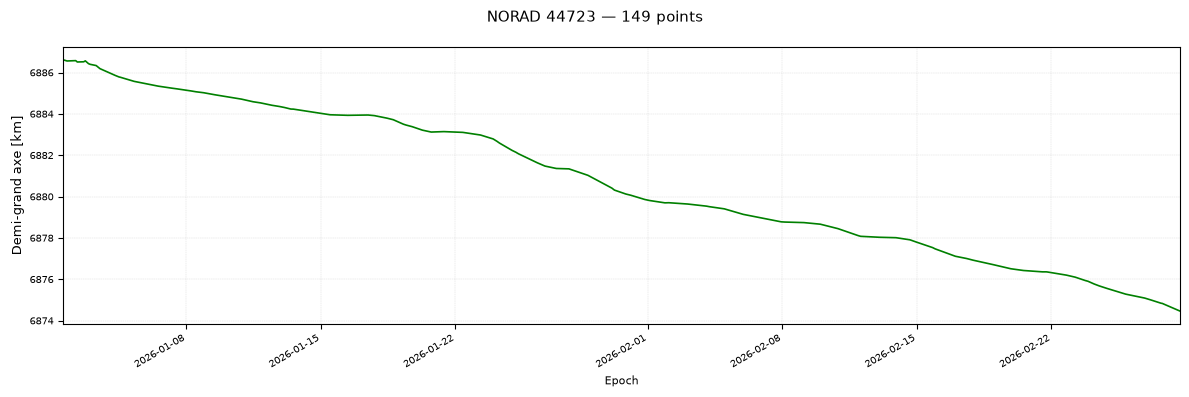

In [3]:
### Graph de sma = semi-grand axe de l'ellipse pour norad = 44723
all_params = ['sma', 'eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion', 'period', 'velocity', 'rev_at_epoch']

fig = plot_time_series(path_starlink, 44723, 'sma')


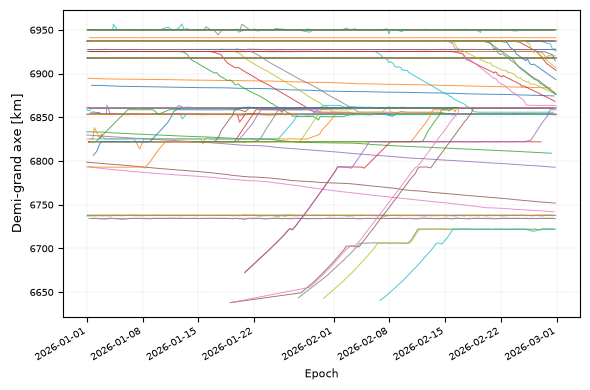

In [4]:
## On superpose les graphes d'un paramètre pour plusieurs satellites 

param = 'sma'
fig = plot_compare(path_starlink, norads, 'sma')

In [5]:
## On voit qu'il n'y a pas de pattern clair lorsqu'on plot les 170 satellites starlink réupérés. 
## Essayons de repérer des constellations : norads commançant par 51, 52, 66 ... 
param = 'sma'

norads_51 = [n for n in norads if str(n).startswith("51")]
fig_51_sma = plot_compare(path_starlink, norads_51, 'sma')
save_fig(fig_51_sma, "norads_51_sma")

norads_52 = [n for n in norads if str(n).startswith("52")]
fig_52_sma = plot_compare(path_starlink, norads_52, 'sma')
save_fig(fig_52_sma, "norads_52_sma")

norads_66 = [n for n in norads if str(n).startswith("66")]
fig_66_sma = plot_compare(path_starlink, norads_66, 'sma')
save_fig(fig_66_sma, "norads_66_sma")

norads_67 = [n for n in norads if str(n).startswith("67")]
fig_67_sma = plot_compare(path_starlink, norads_67, 'sma')
save_fig(fig_67_sma, "norads_67_sma")


Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/norads_51_sma.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/norads_52_sma.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/norads_66_sma.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/norads_67_sma.png


Parmi les constellations 66 et 67, qui sont récentes (lancement de 67050 en décembre 2025 par exemple), on remarque des variations de demi grand axe pour converger jusqu'à un "demi-grand axe d'équilibre" pour la constellation. Testons les autres paramètres orbitaux.

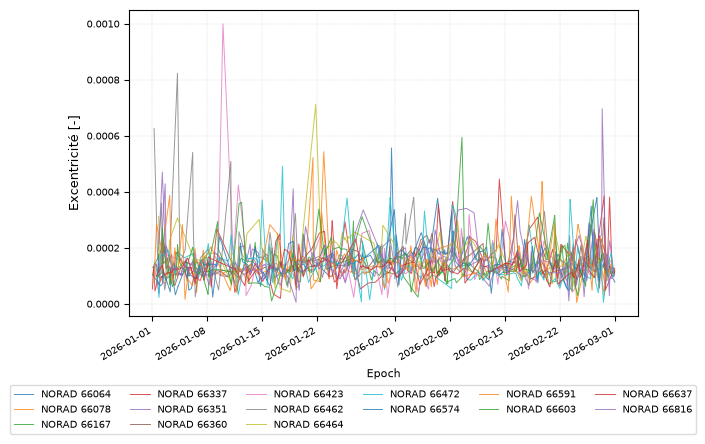

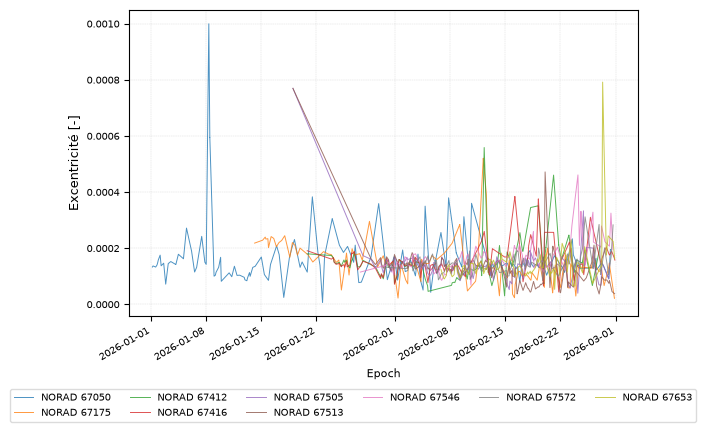

In [6]:
## Range manuelle des params, utile pour viz claire
ylim={"eccentricity" : (0, 0.001) , "inclination" : (0, 360)}

## Eccentricité

fig_66_ecc = plot_compare(path_starlink, norads_66, 'eccentricity', ylim=ylim)
fig_67_ecc = plot_compare(path_starlink, norads_67, 'eccentricity', ylim=ylim)




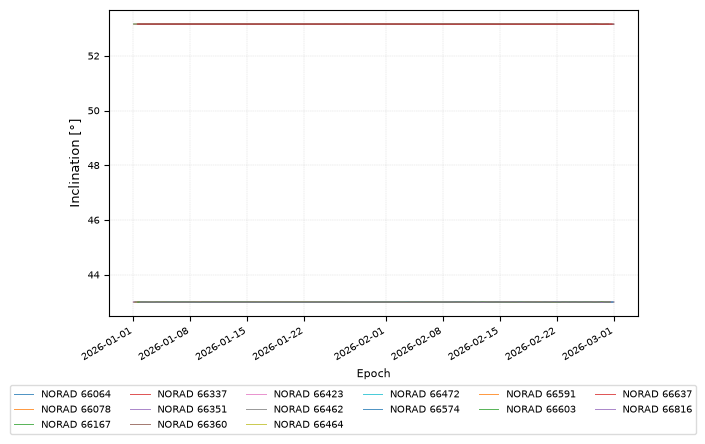

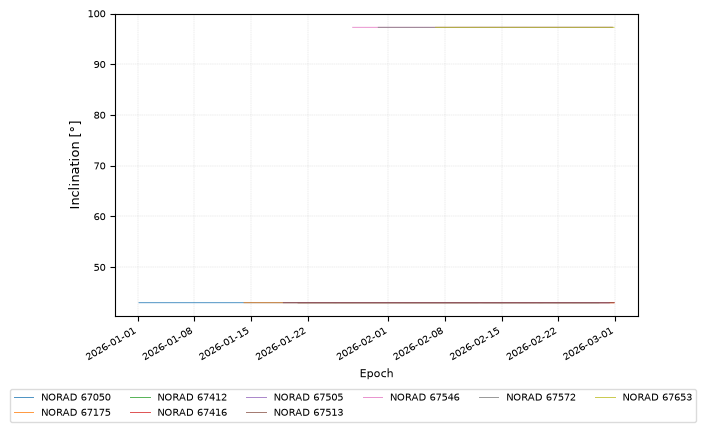

In [7]:
#Inclinaison

fig_66_inc = plot_compare(path_starlink, norads_66, 'inclination', ylim=ylim)
fig_67_inc= plot_compare(path_starlink, norads_67, 'inclination', ylim=ylim)

On voit qu'il y a plusieurs constellations au sein des norads starlink 66, 67, avec différentes inclinaisons. Concentrons nous sur les différentes constellations au sein des norads 66.

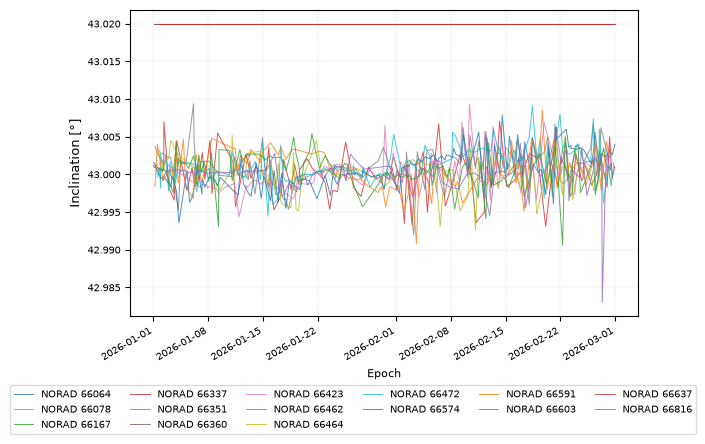

In [8]:
ylim={"eccentricity" : (0, 0.001) , "inclination" : (42.98,43.02)}
fig_66_inc_cluster_1 = plot_compare(path_starlink, norads_66, 'inclination', ylim=ylim)



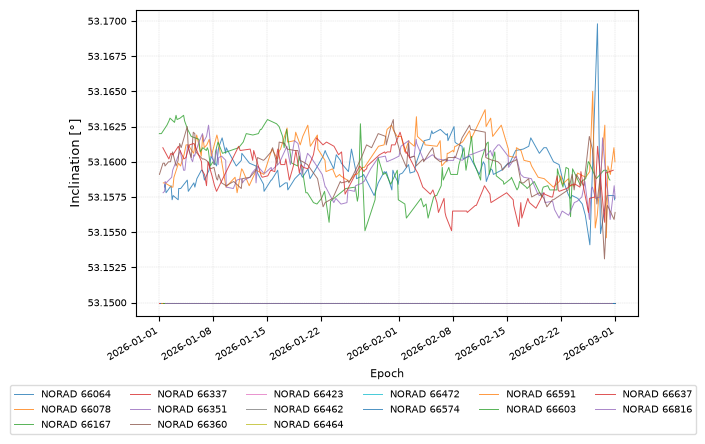

In [9]:
ylim_1 ={"eccentricity" : (0, 0.001) , "inclination" : (53.15,53.175)}
fig_66_inc_cluster_2 = plot_compare(path_starlink, norads_66, 'inclination', ylim=ylim_1)

Étudions plus en détail le cluster 1 tiré des norads Starlink 66 : 
- 

En traçant l'ensemble des paramètres on voit que l'on pouvait encore distinguer plusieurs groupes de satellites. Le cluster_1_66 final contient les norads cités ci-dessous, et constitue notre premier exemple de constellation.

In [10]:
cluster_66_1 = [66337, 66423, 66464, 66472, 66574, 66591, 66603, 66816]
ylim={"eccentricity" : (0, 0.001) , "inclination" : (42.98,43.02)}
figs_cluster_1 = {}
all_params = ['sma', 'eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion', 'period', 'velocity', 'rev_at_epoch']
for param in all_params:
    fig = plot_compare(path_starlink, cluster_66_1, param, ylim=ylim)
    figs_cluster_1[param] = fig
for param, fig in figs_cluster_1.items():
    save_fig(fig, f"cluster_66_1_{param}")


Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/cluster_66_1_sma.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/cluster_66_1_eccentricity.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/cluster_66_1_inclination.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/cluster_66_1_raan.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/cluster_66_1_arg_perigee.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/cluster_66_1_mean_anomaly.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/cluster_66_1_mean_motion.png
Figur

Comme dans [2025 Cipollone], il sera pertinent lors de la phase de ML de ne pas fournir l'anomalie moyenne M et le RAAN, car M wrappe très rapidement sur une journée (et son information est déjà codée dans la periode de l'orbite, donc le demi-grand axe). Et RAAN varie de manière déterministe, et n'apporte rien en termes d'information sur une éventuelle manoeuvre.
___ 

### Conclusion 
Les satellites Starlink orbitent en LEO (a ~ 6860km par ex) avec orbite quasi-circulaire (e~10e-4). On remarque des manoeuvres qui on ici surement pour but un changement d'orbite/mise en orbite d'équilibre.

### 


# Les satellites chinois
On récupère pour cette partie tous les satellites catalogués comme chinois de SpaceTrack (PRC), entre le 1er Janvier 2026 et le 1er avril 2026. 

In [11]:
## paramètres 
path_prc = ROOT / "data" / "raw" / "ALL_PRC_1782736576.8100522.parquet"
norads_prc = pl.scan_parquet(path_prc).select("norad").unique().sort("norad").collect().to_series().to_list()
print(f"{len(norads_prc)} différents récupérés")
print(f"Un norad au hasard : {norads_prc[0]}")

239 différents récupérés
Un norad au hasard : 18922


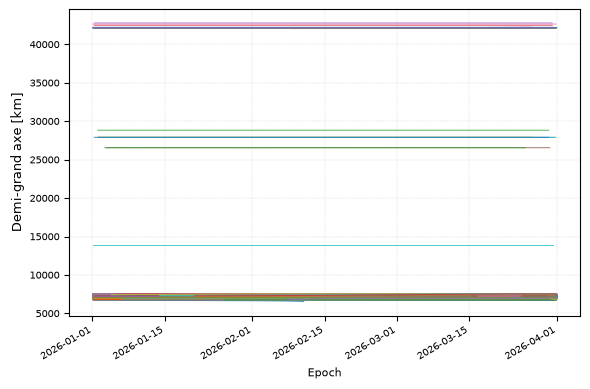

In [12]:

param = 'sma'
fig = plot_compare(path_prc, norads_prc, 'sma')

On observe que les données récupérées des satellites chinois ont des types d'orbites variées: 
- LEO : orbite entre 200 - 2000km autour de la terre
- MEO : entre 2000 et 35786km 
- GEO : 35786km (orbite géostationnaire)
- Orbites haute >= 35786km

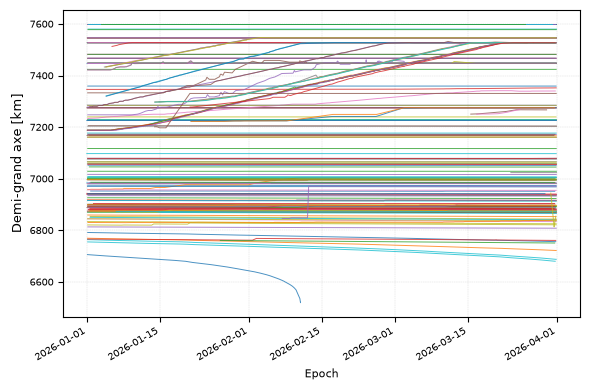

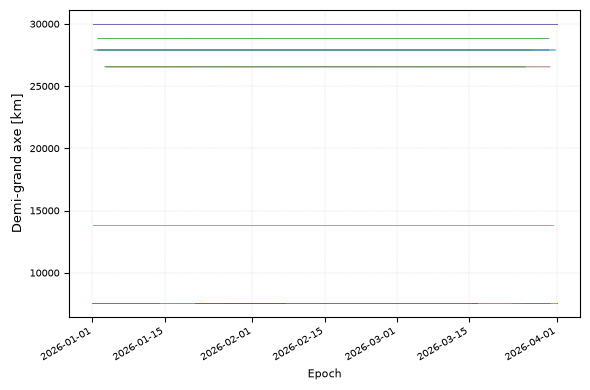

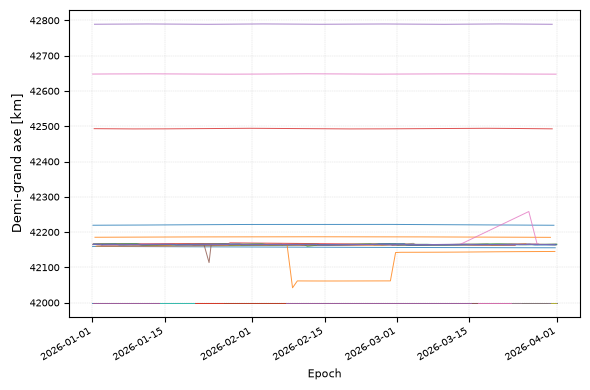

In [13]:
ylim_LEO={"sma" : (6500, 7600)}
ylim_MEO={"sma" : (7600, 30000)}
ylim_GEO={"sma" : (42000, 45000)}
fig_PRC_LEO = plot_compare(path_prc, norads_prc, 'sma', ylim=ylim_LEO)
fig_PRC_MEO = plot_compare(path_prc, norads_prc, 'sma', ylim=ylim_MEO)
fig_PRC_GEO = plot_compare(path_prc, norads_prc, 'sma', ylim=ylim_GEO)


On va essayer de se focaliser sur les orbites des satellites géostationnaires. Leurs orbites devrait être de semi-grand axe $a = r_{GEO} + r_{Terre} = 35786 + 6378 = 42164 \quad \text{km}$

Satellites chinois en orbite GEO : 16


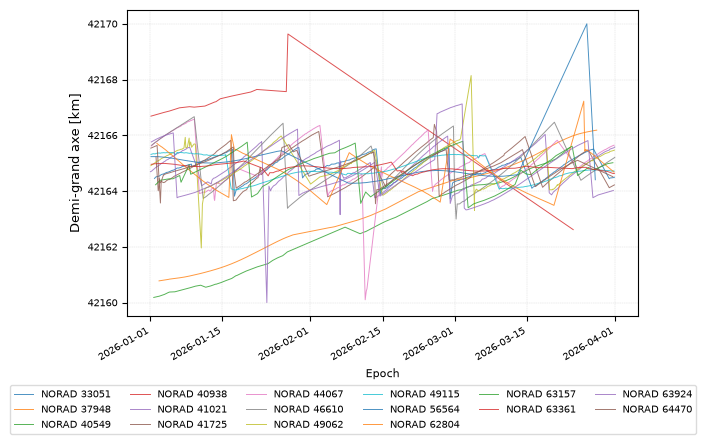

In [14]:
ylim_GEO = {"sma" : (42160, 42170)}
norads_PRC_GEO = []
for n in norads_prc:
    sma = pl.scan_parquet(path_prc).filter(pl.col("norad") == n).select("sma").collect().to_series().mean()
    if 42160 <= sma <= 42170:
        norads_PRC_GEO.append(n)

print(f"Satellites chinois en orbite GEO : {len(norads_PRC_GEO)}")

fig_PRC_GEO = plot_compare(path_prc, norads_PRC_GEO, 'sma', ylim=ylim_GEO) 

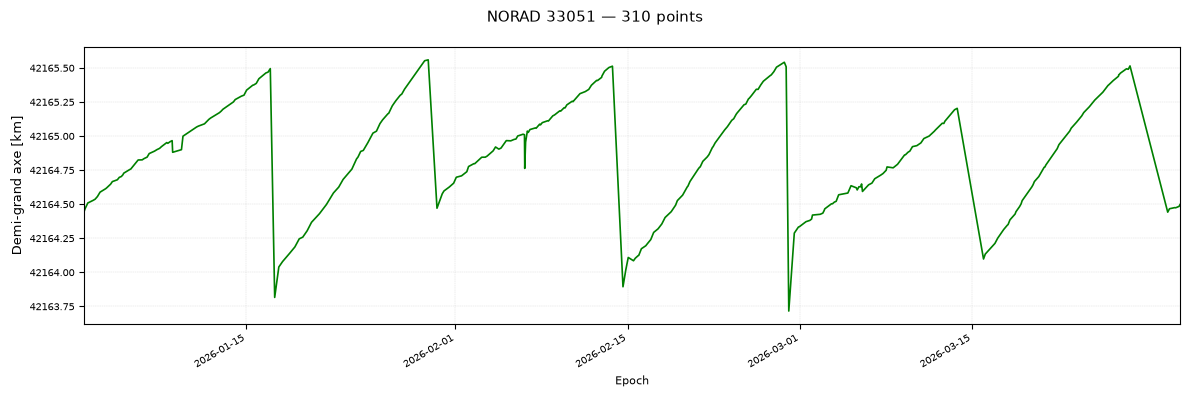

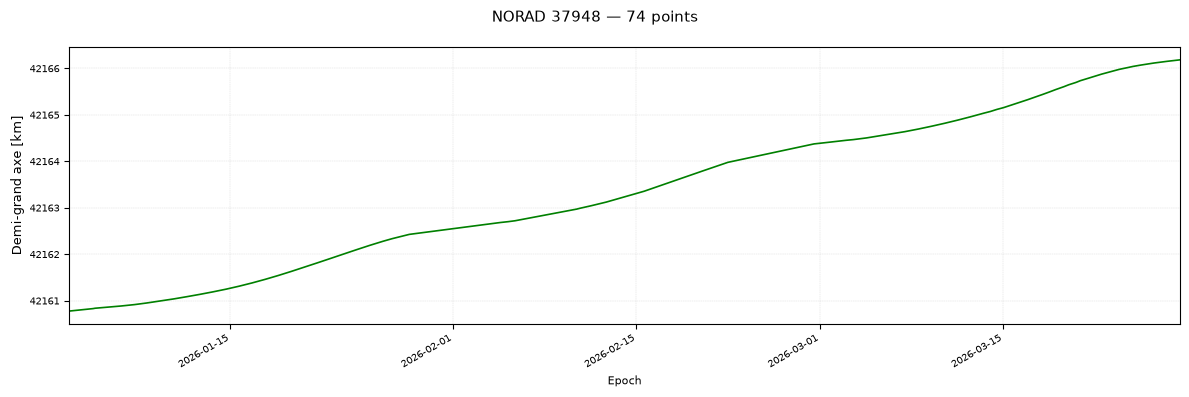

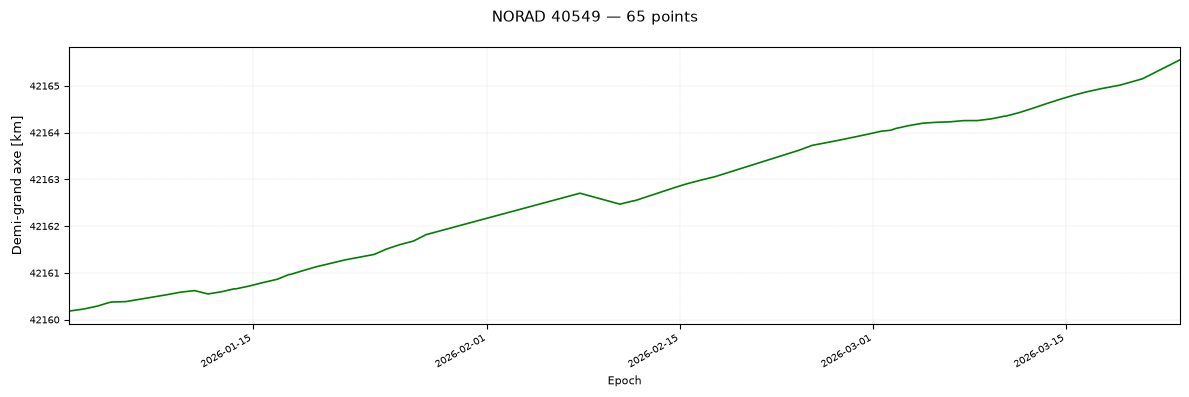

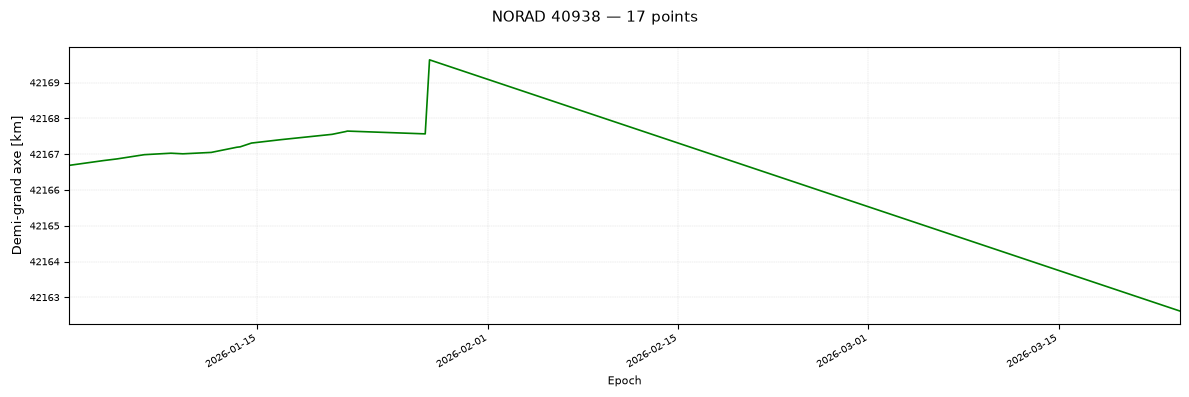

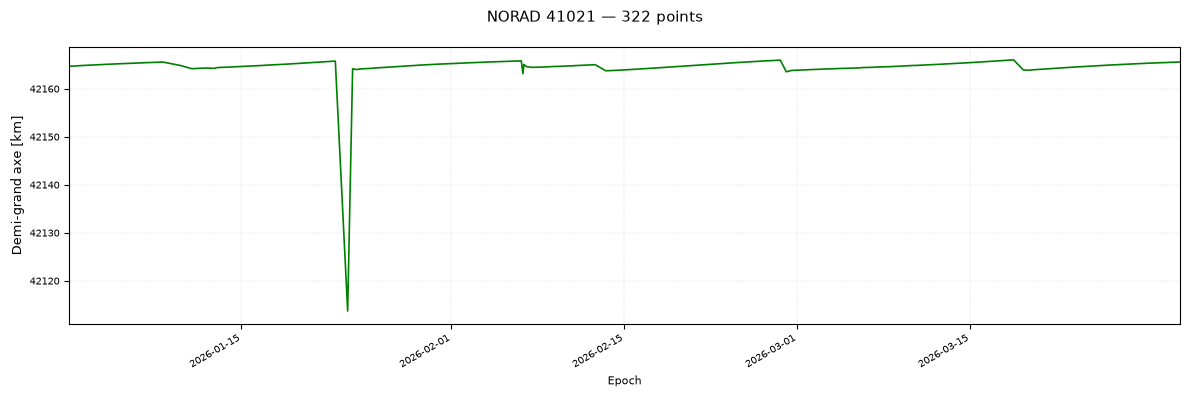

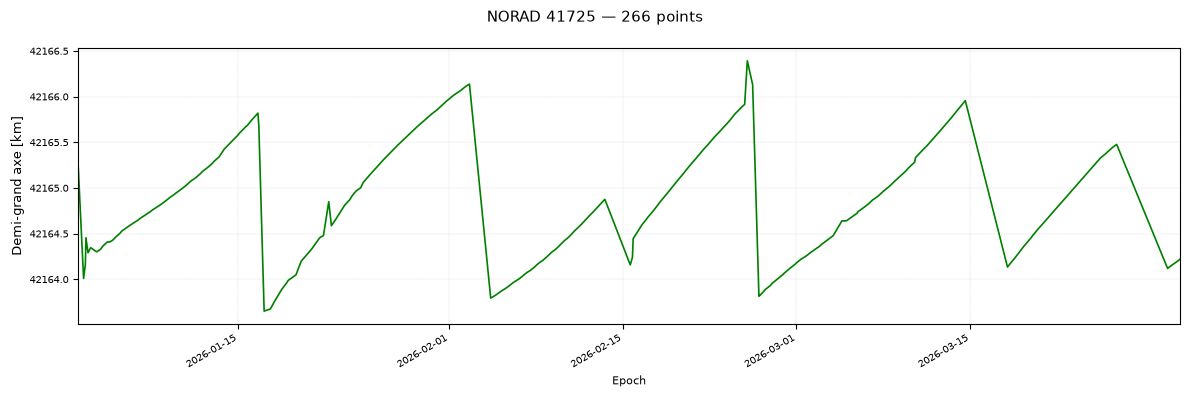

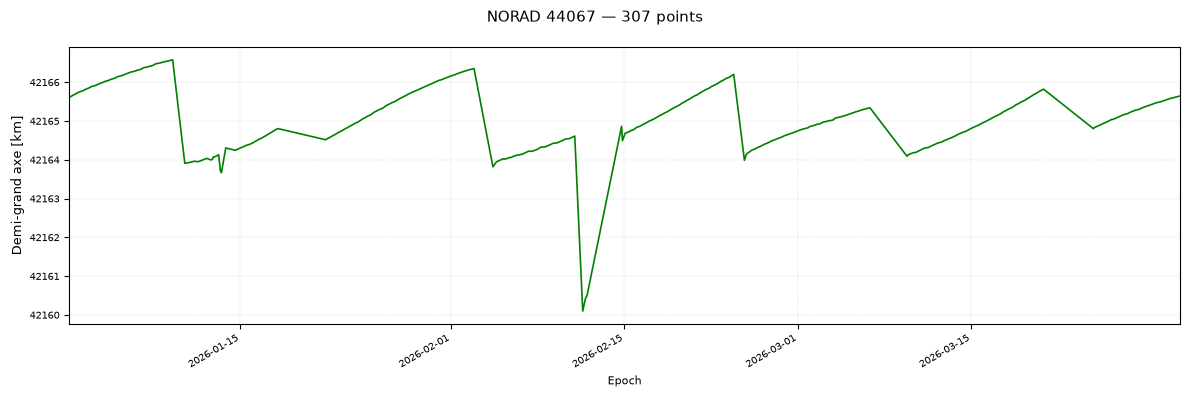

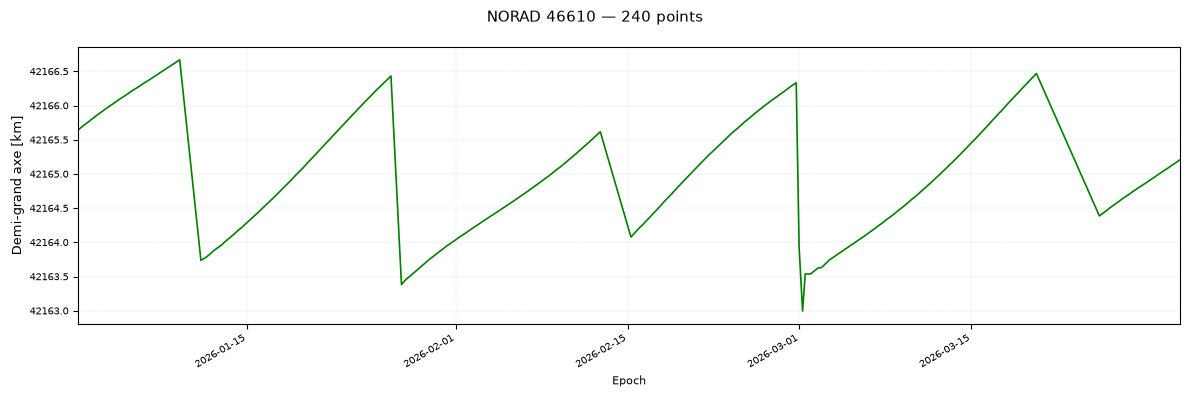

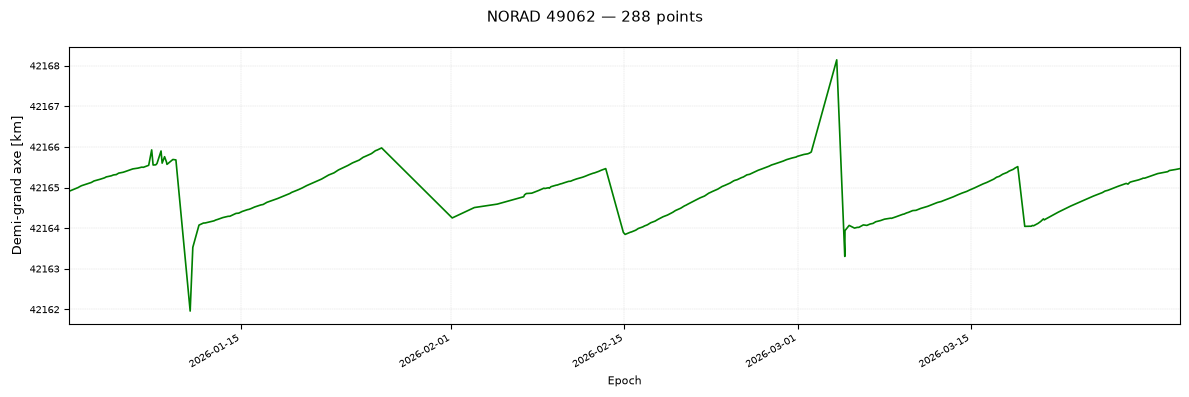

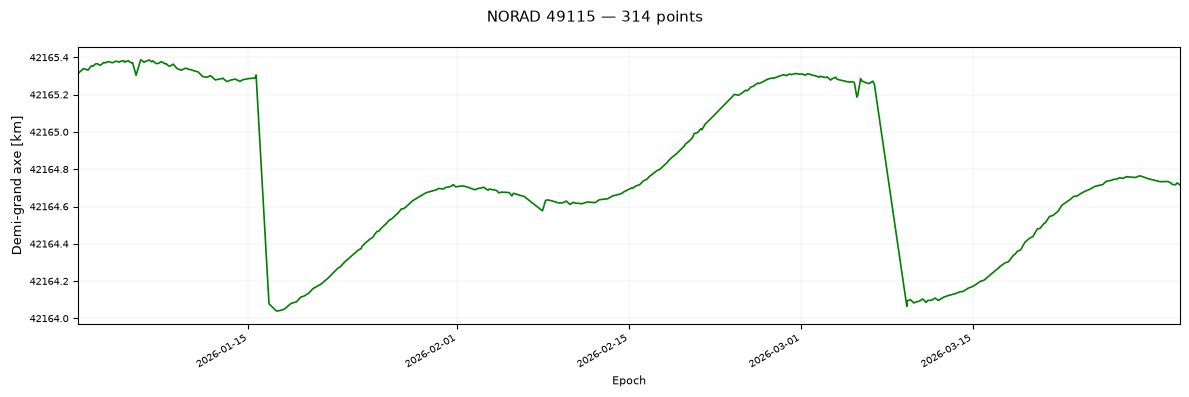

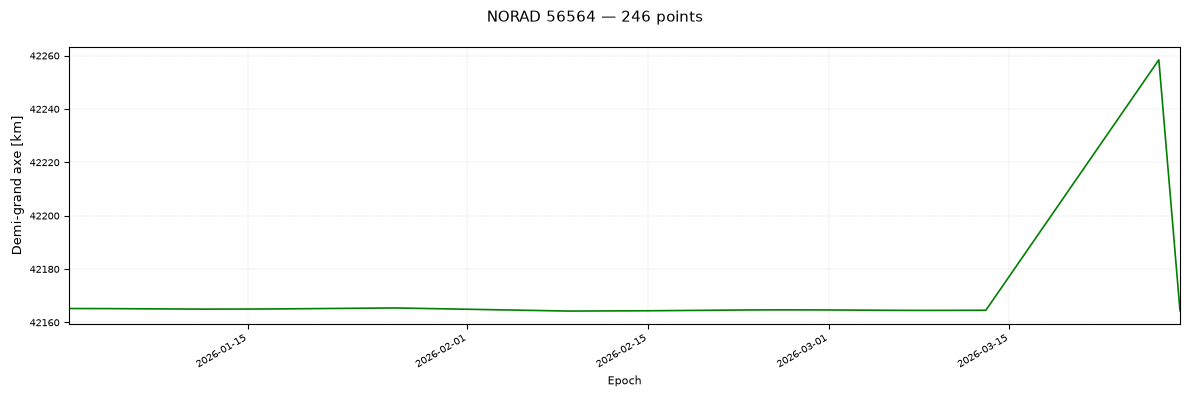

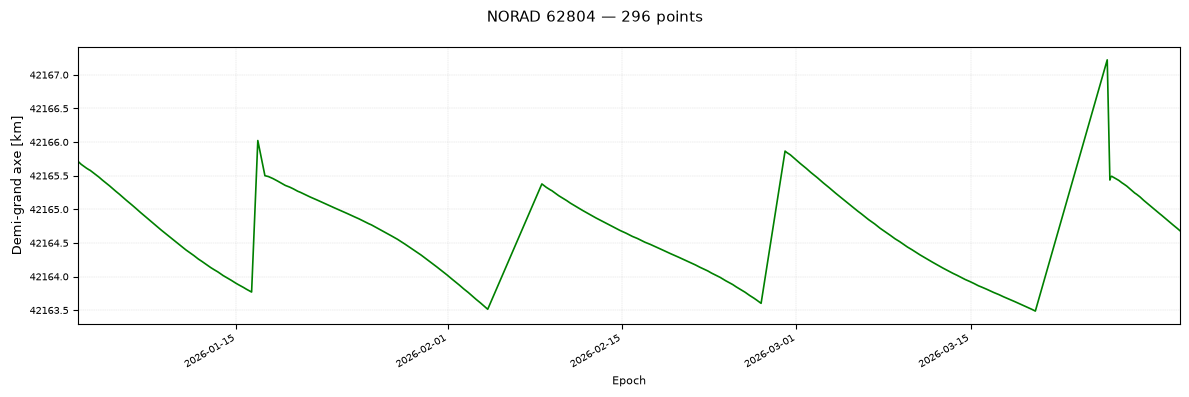

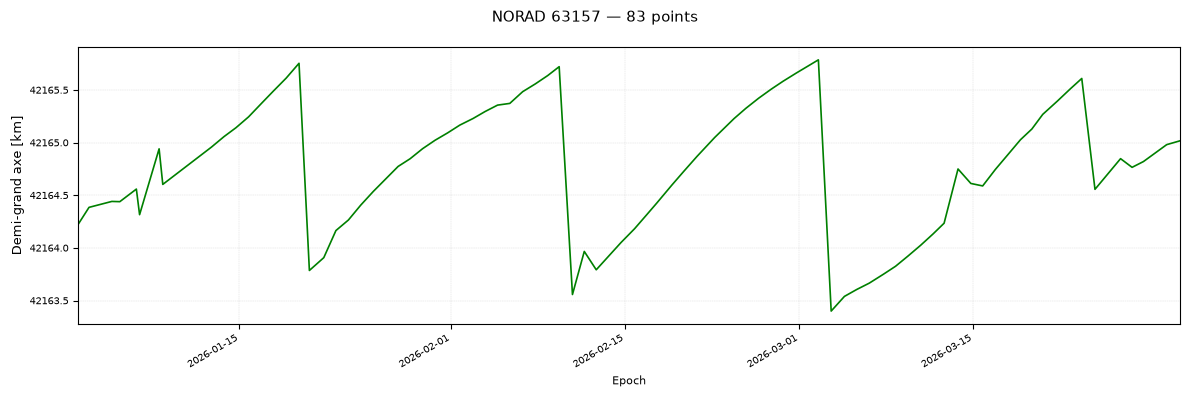

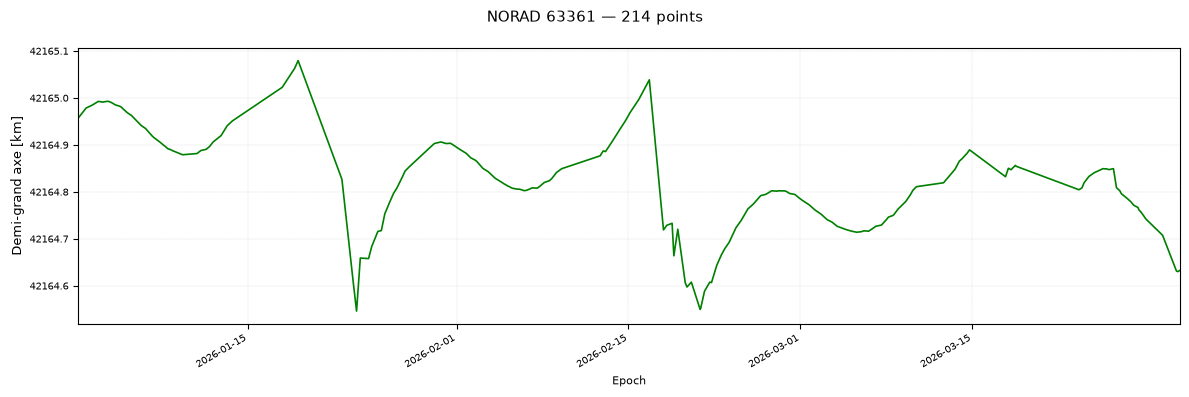

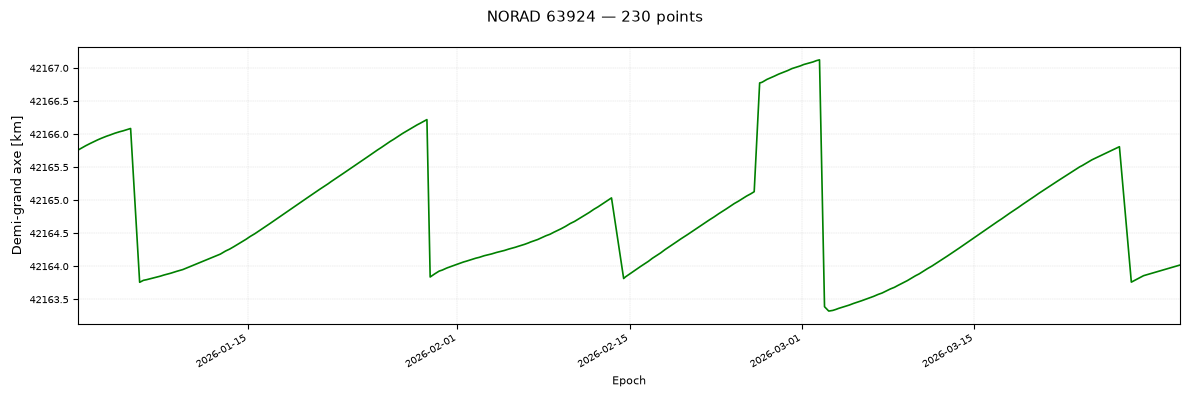

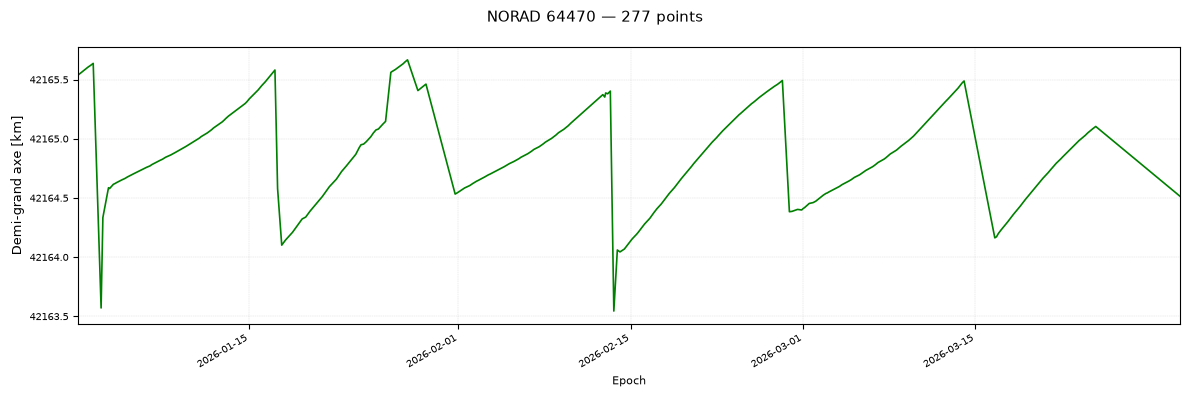

In [15]:

for n in norads_PRC_GEO:
    fig = plot_time_series(path_prc, n, ['sma'])


On voit clairement les manoeuvres orbitales dans le cas des orbites GEO. Les orbites GEO vont être particulièrement intéressantes pour nous. 
On trace les autres paramètres pour le norad 33051

Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/norad_33051_all_params.png


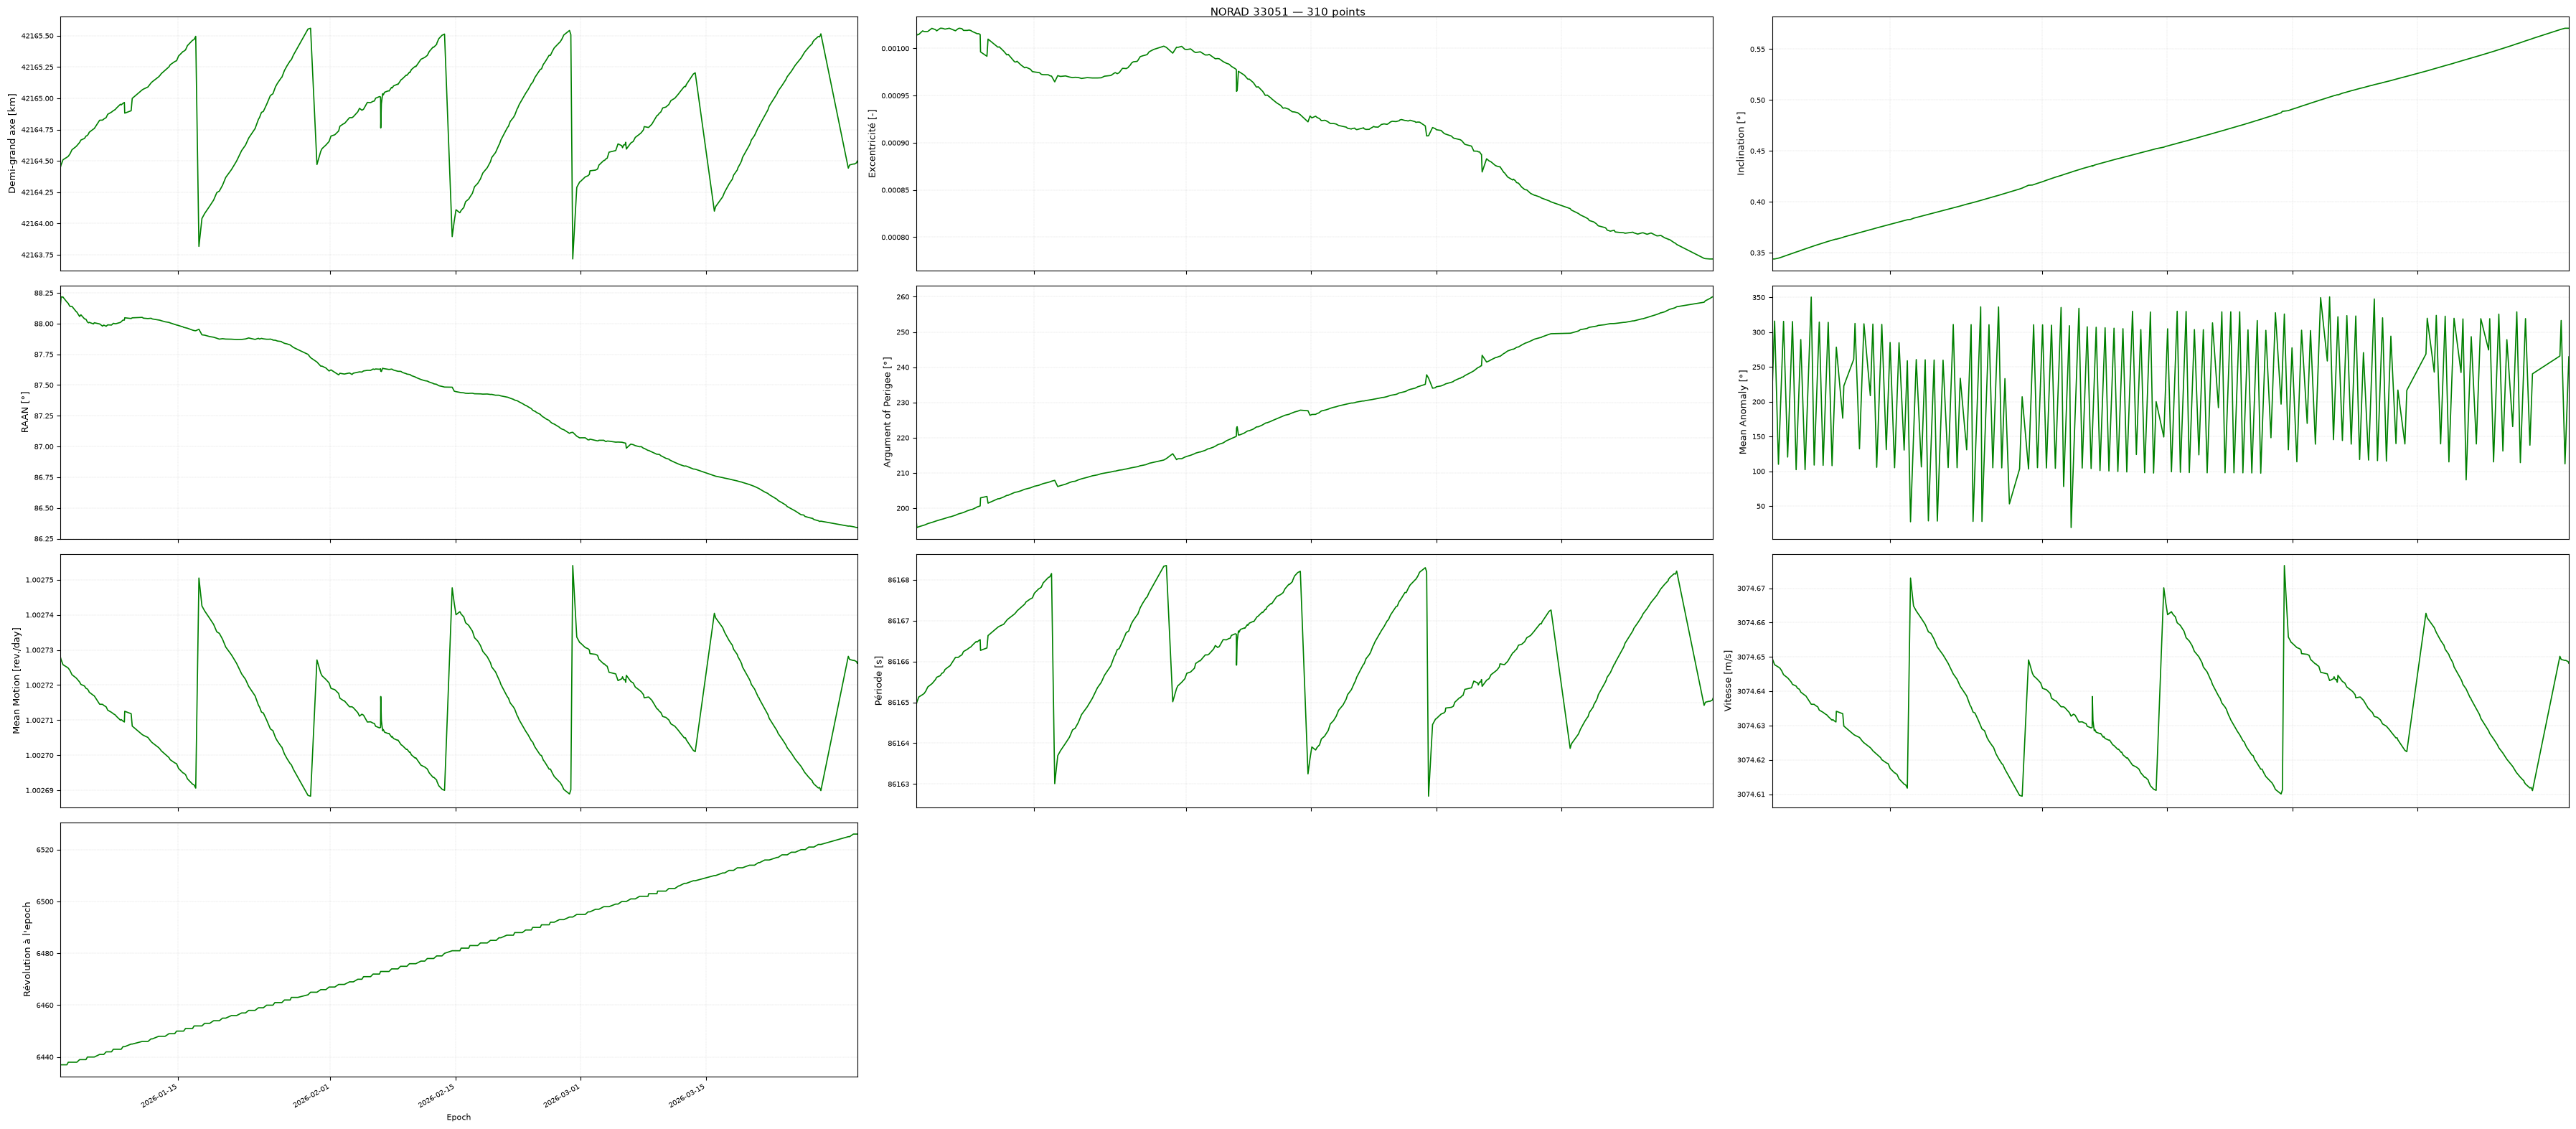

In [16]:
norad = 33051

params = ['sma', 'eccentricity', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion', 'period', 'velocity', 'rev_at_epoch']

plot_time_series(path_prc, norad, params)
save_fig(fig, f"norad_{norad}_all_params")

On voit sur la courbe du semi-grand axe des manoeuvres de modification du type $\Delta a = - 1km$ qui vise à replacer le satellite sur l'orbite géosynchrone, en faisant varier l'altitude dans le plan orbital.

De même, des variations de $i$ et $\Omega$ vise à replacer le satellite à la bonne latitude Nord-Sud. 

Une variation de l'excentricité $e$ peut être due à un replacement Est-Ouest. 

# Satellites géosynchrones


On s'attarde sur le cas des satellites GEO pour lesquels ont peut facilement détecter des manoeuvres à travers les courbes historiques des éléments orbitaux. 

In [17]:
### Recup de la data GEO de SpaceTrack (via orbit_range dans data.yaml)
path_geo = ROOT / "data" / "raw" / "ALL_ALL_1782740361.841526.parquet"
norads_geo = pl.scan_parquet(path_geo).select("norad").unique().sort("norad").collect().to_series().to_list()
print(f"{len(norads_geo)} norads en GEO récupérés, tous types de satellites confondus.")


299 norads en GEO récupérés, tous types de satellites confondus.


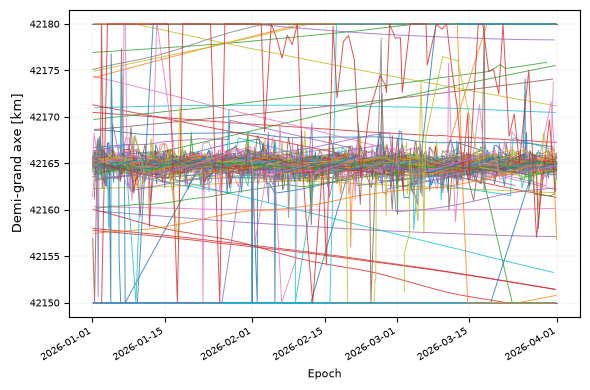

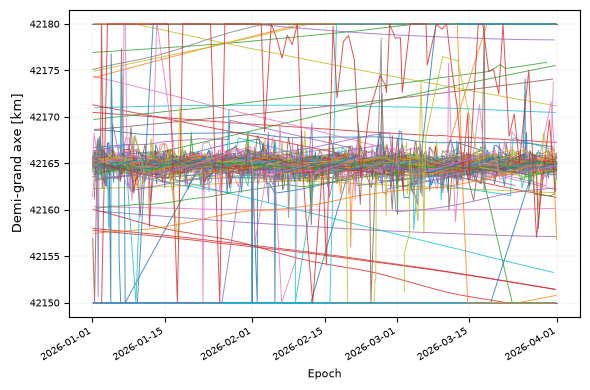

In [18]:
ylim_GEO = {"sma" : (42150, 42180)}
plot_compare(path_geo, norads_geo, "sma", ylim=ylim_GEO)

Après zoom sur l'orbite géosynchrone, on obtient 131 satellites
On trace les séries temporelles de 20 satellites choisis au hasard dans cette liste


/Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/src/viz/time_series.py:115: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, 4 * nrows), squeeze=False)


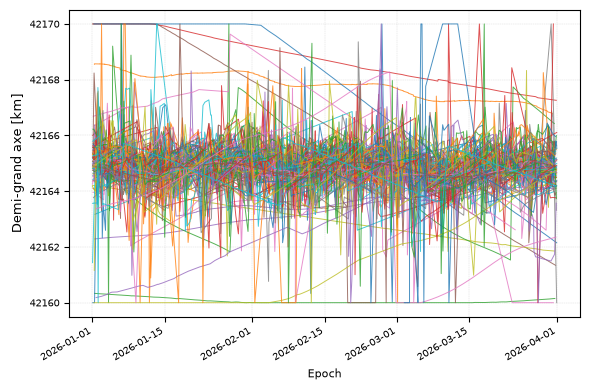

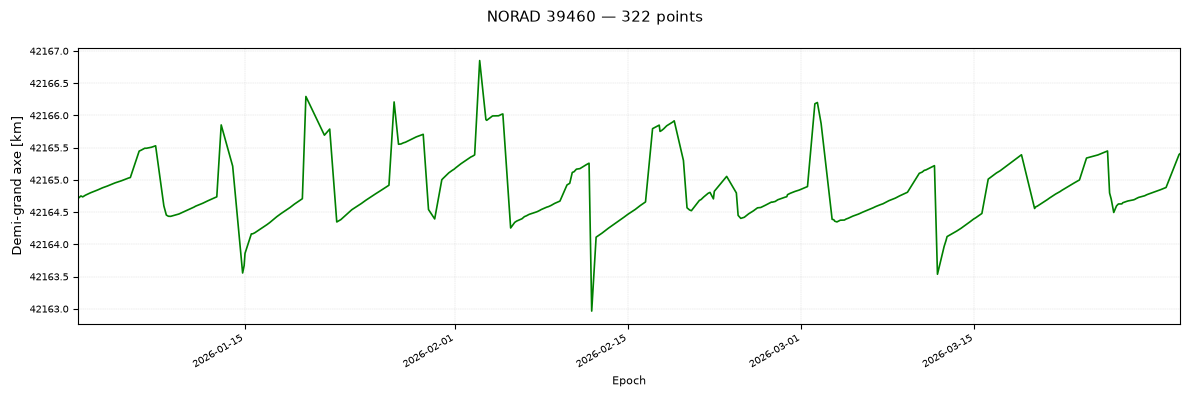

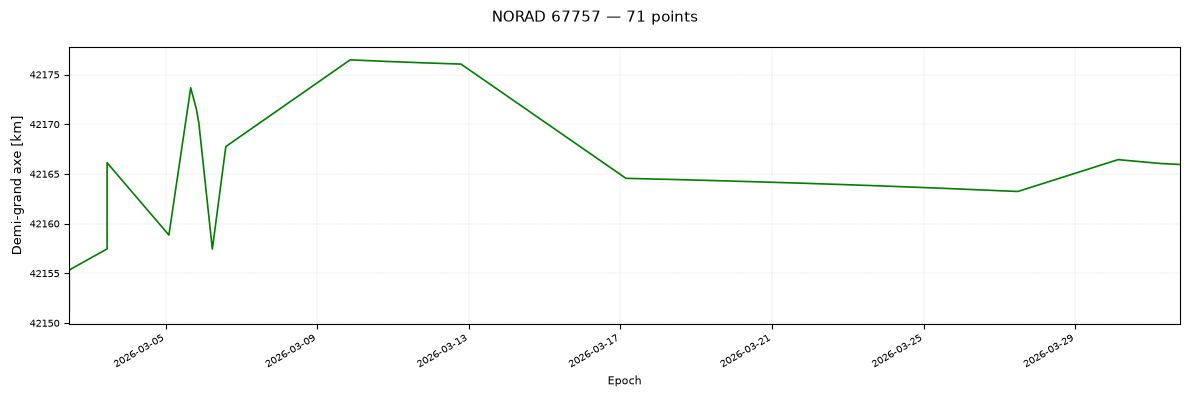

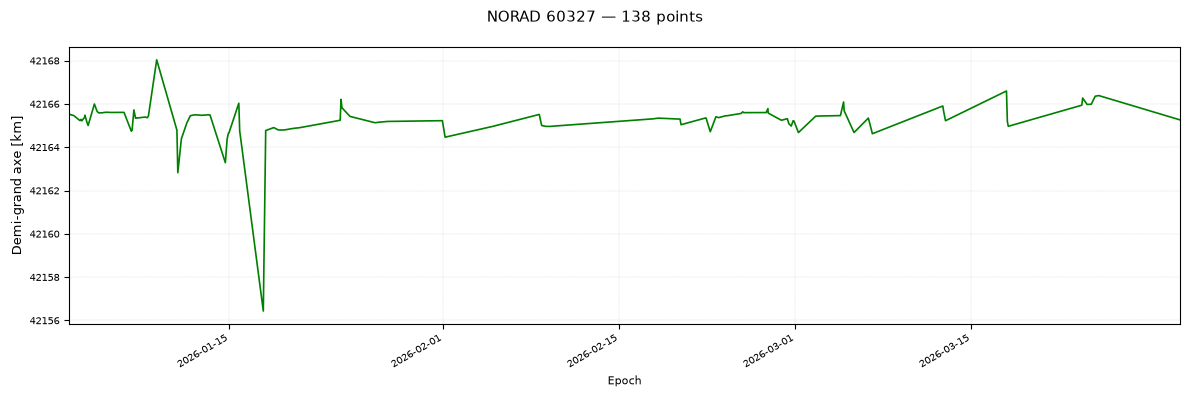

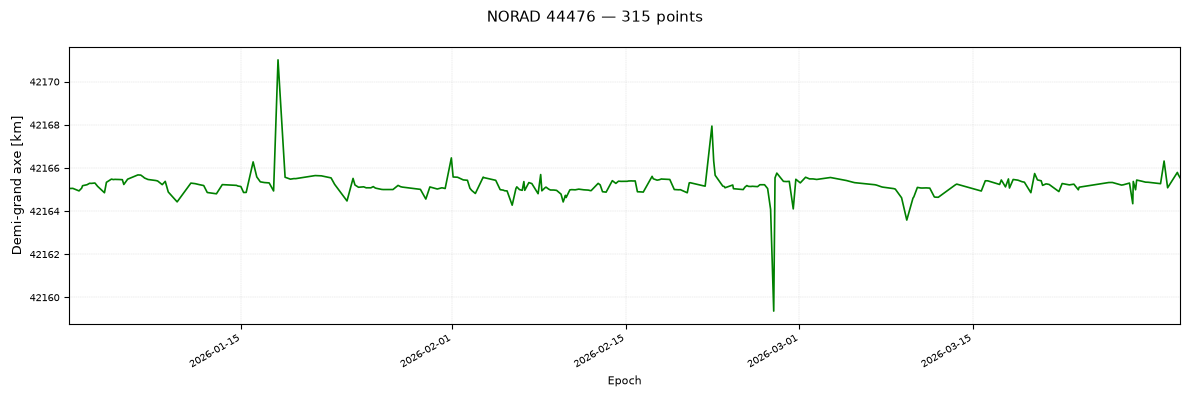

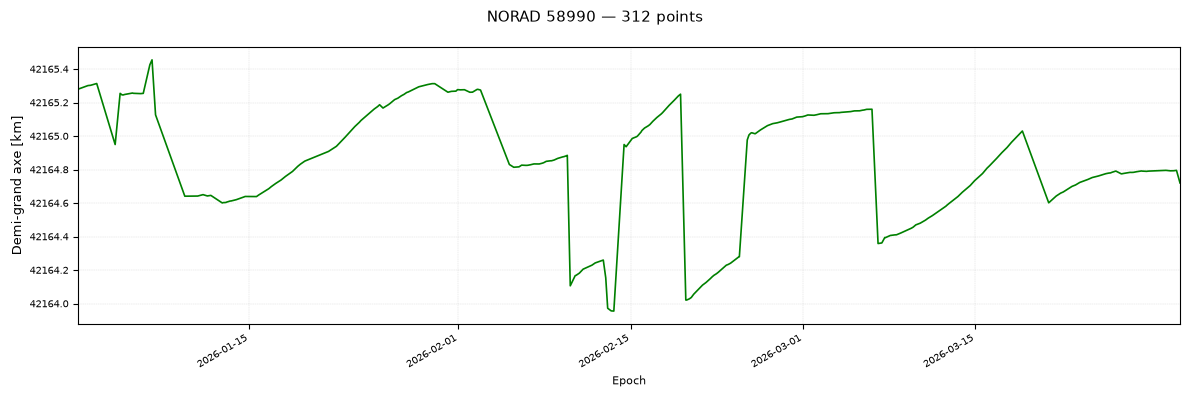

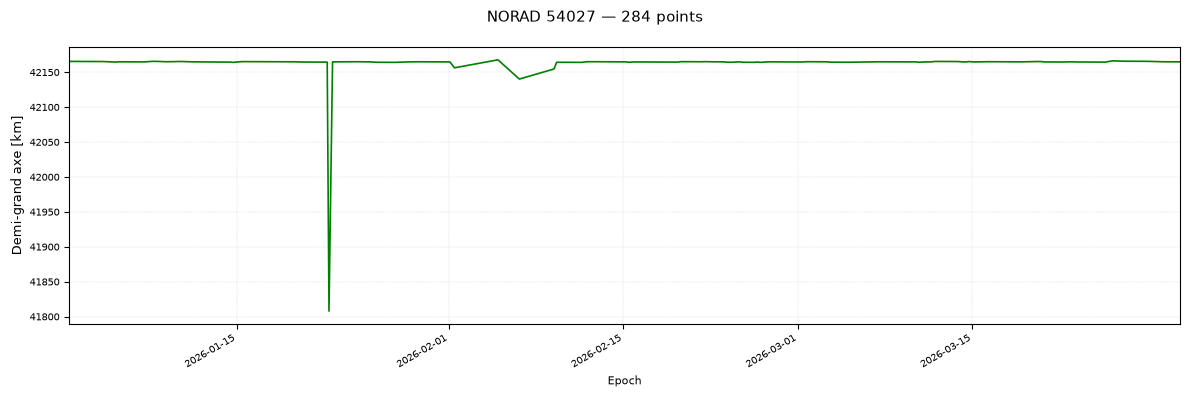

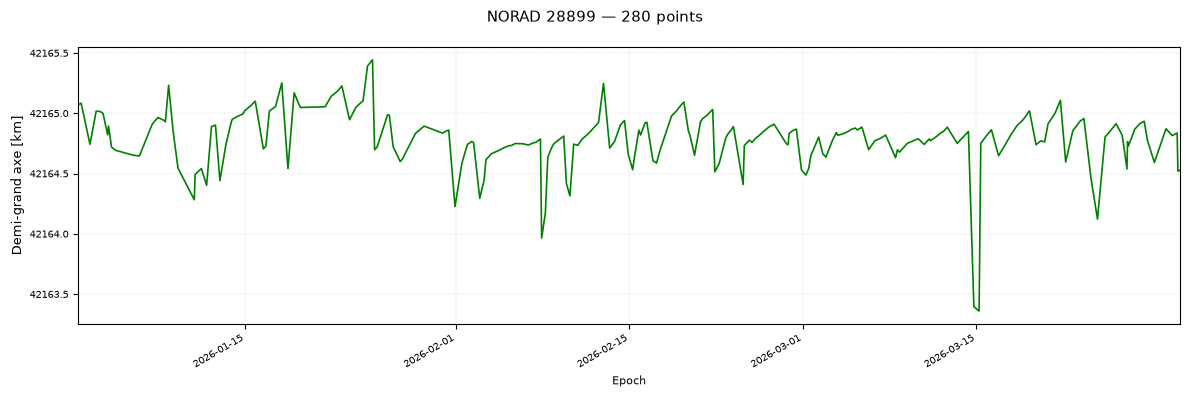

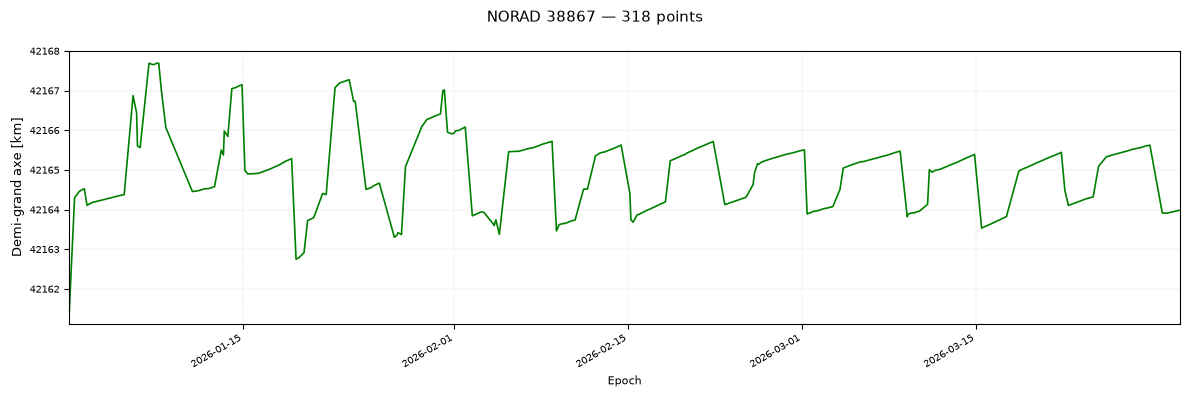

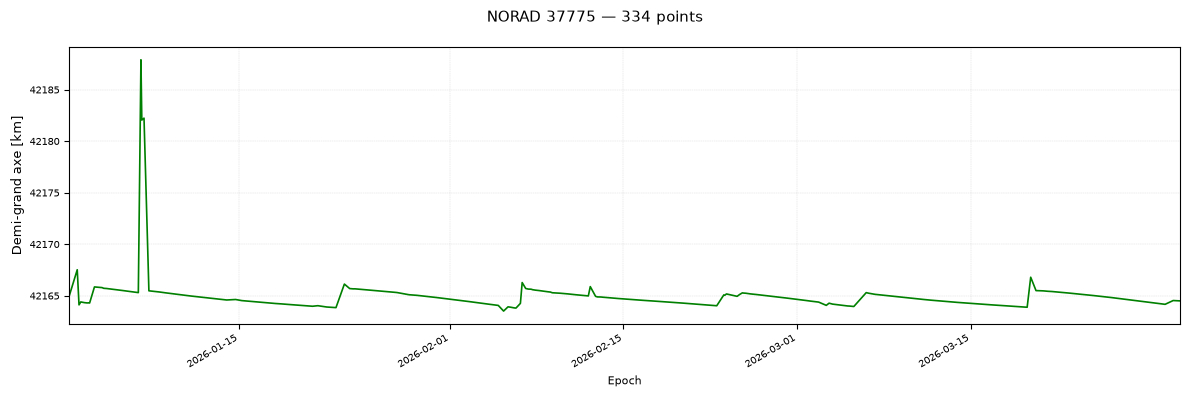

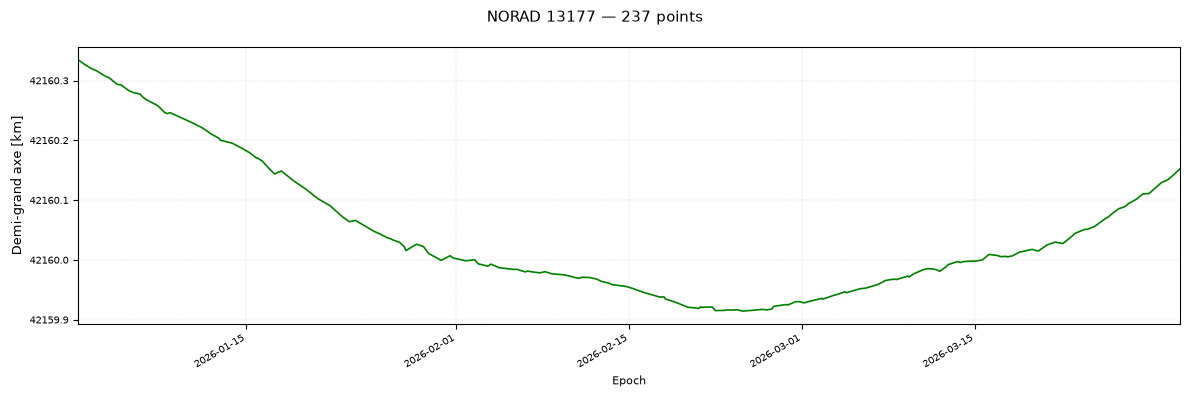

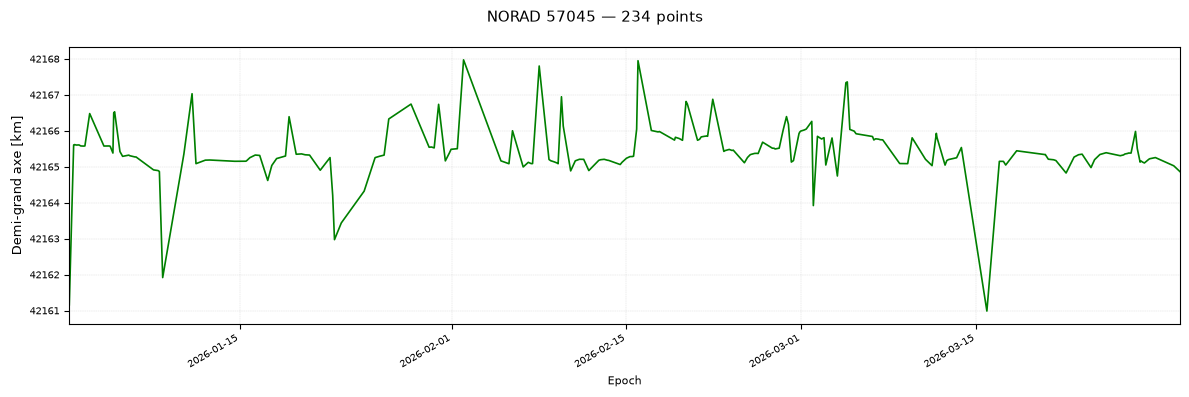

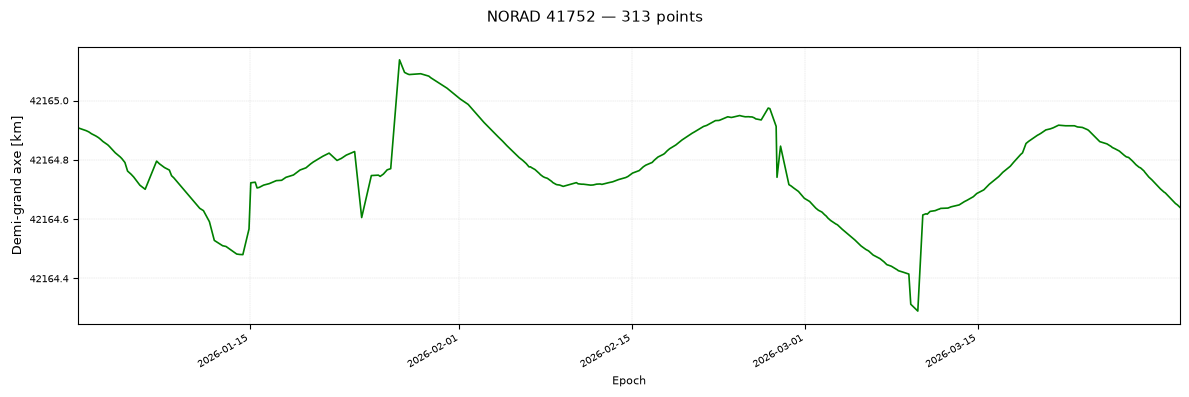

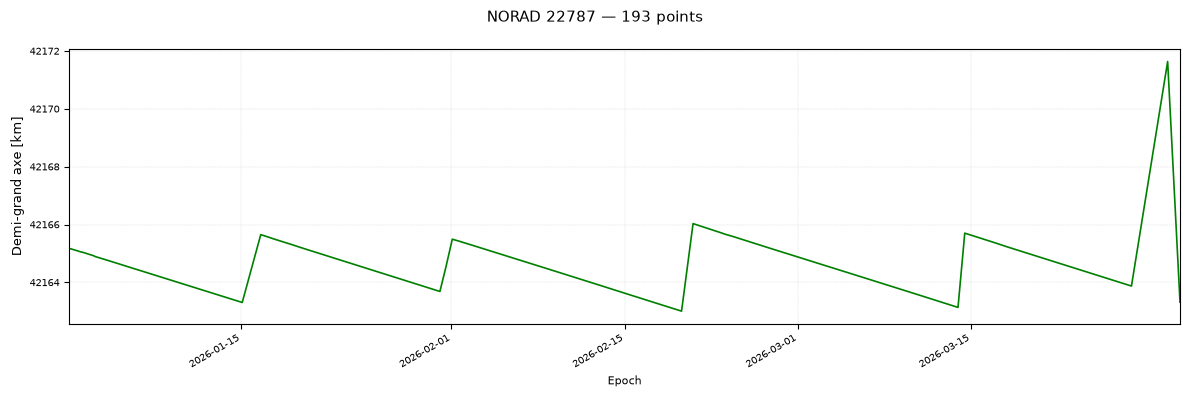

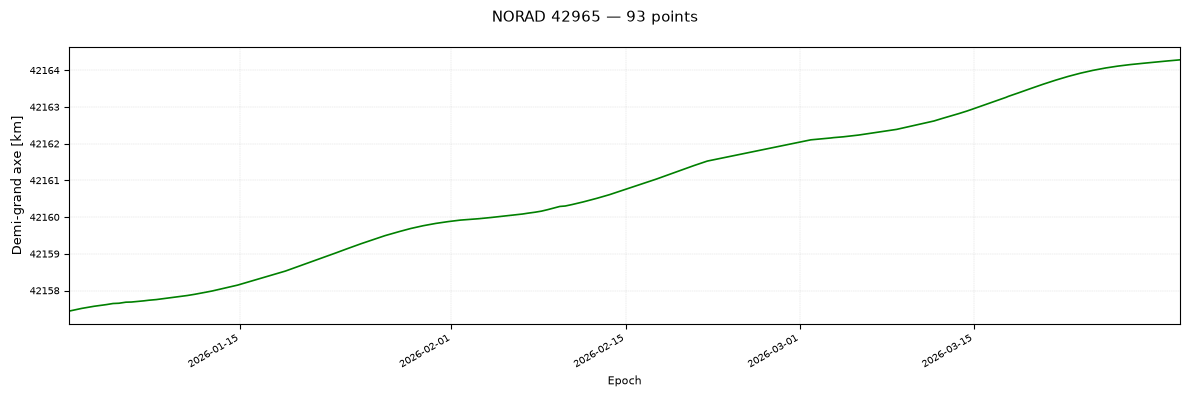

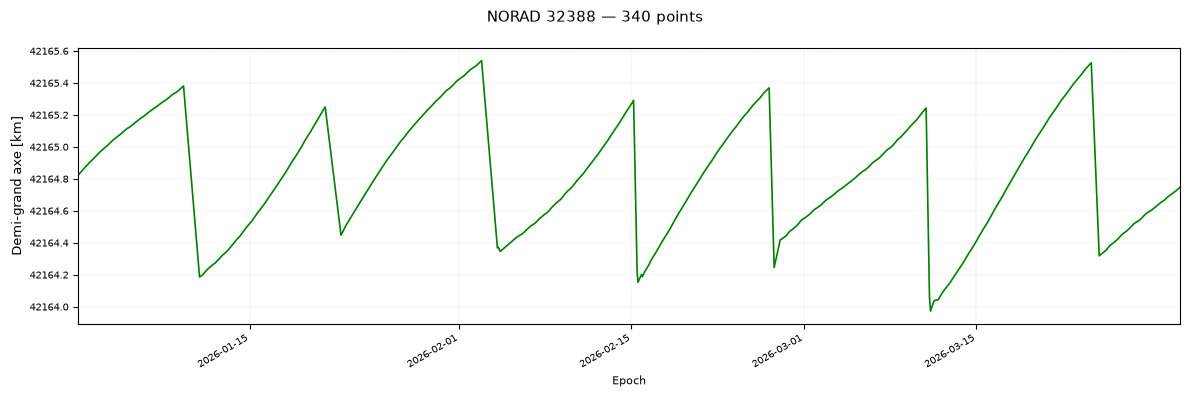

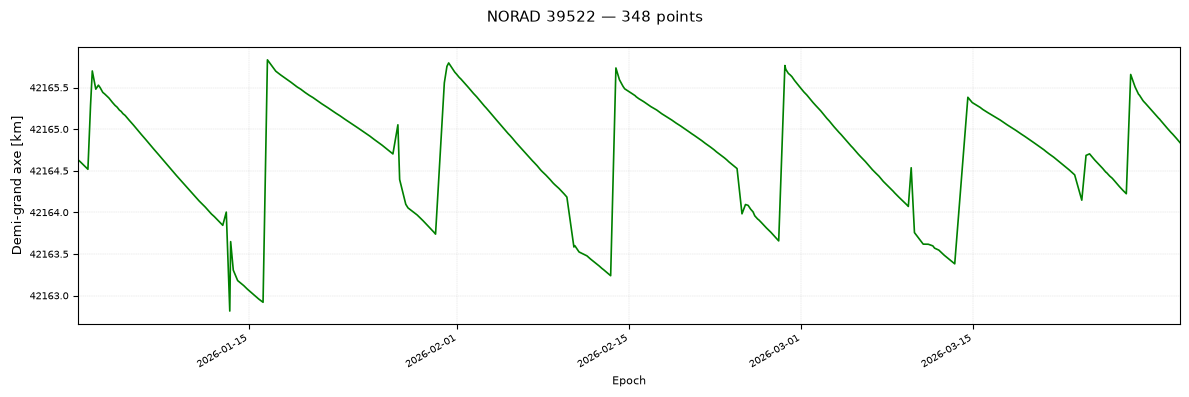

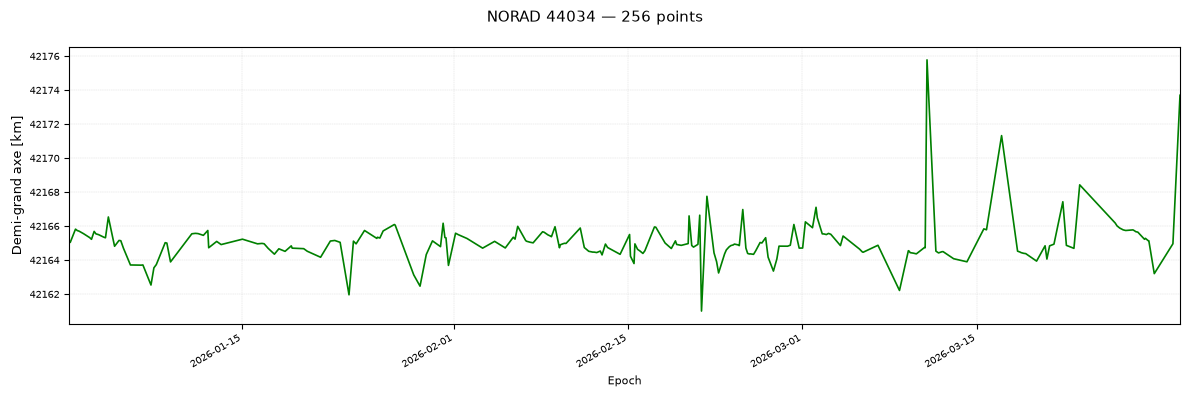

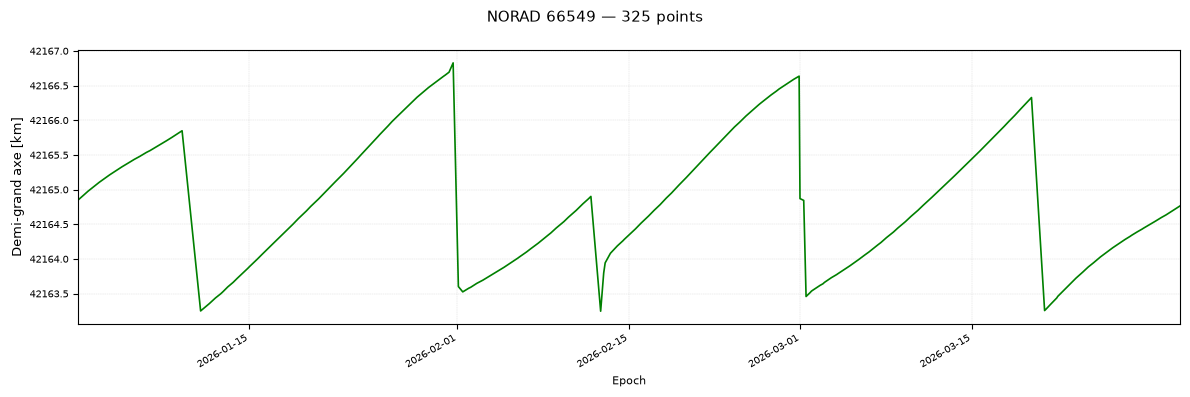

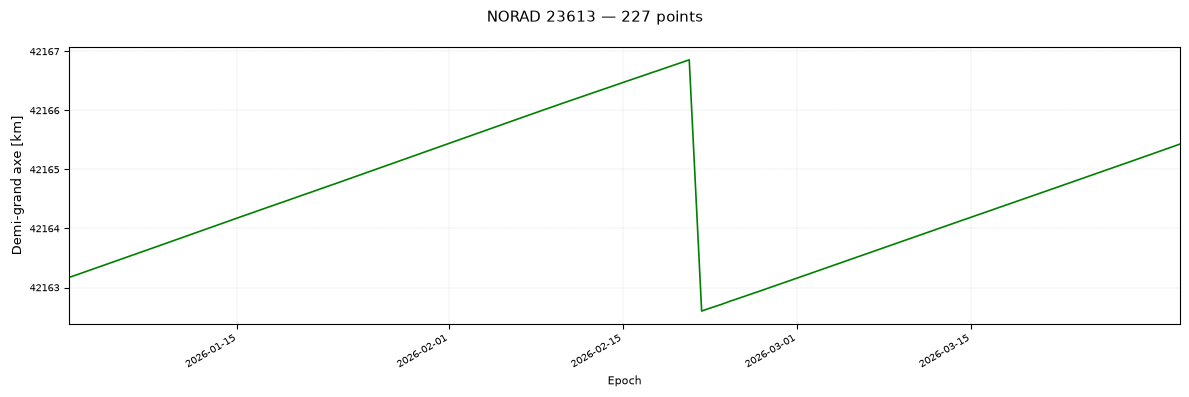

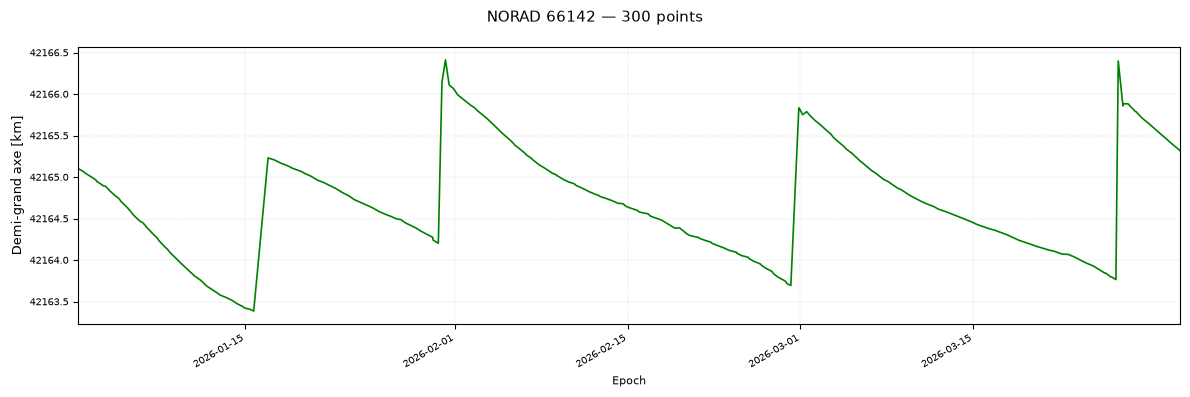

In [19]:
## On fait un premier nettoyage en ne gardant que les satellites vraiment en orbite géosynchrone : 
norads_GEO_ = []
for n in norads_geo:
    sma = pl.scan_parquet(path_geo).filter(pl.col("norad") == n).select("sma").collect().to_series().mean()
    if 42160 <= sma <= 42170:
        norads_GEO_.append(n)

print(f"Après zoom sur l'orbite géosynchrone, on obtient {len(norads_GEO_)} satellites")
ylim_GEO = {"sma" : (42160, 42170)}
plot_compare(path_geo, norads_GEO_, "sma", ylim=ylim_GEO)

import random 
print("On trace les séries temporelles de 20 satellites choisis au hasard dans cette liste")
sub_norads_geo = random.sample(norads_GEO_, 20 ) 
for n in sub_norads_geo : 
    plot_time_series(path_geo, n, 'sma')


Ces 130 NORADS de satellites pourraient fournir une solide base de données pour débuter de la détection de manoeuvre en GEO. 

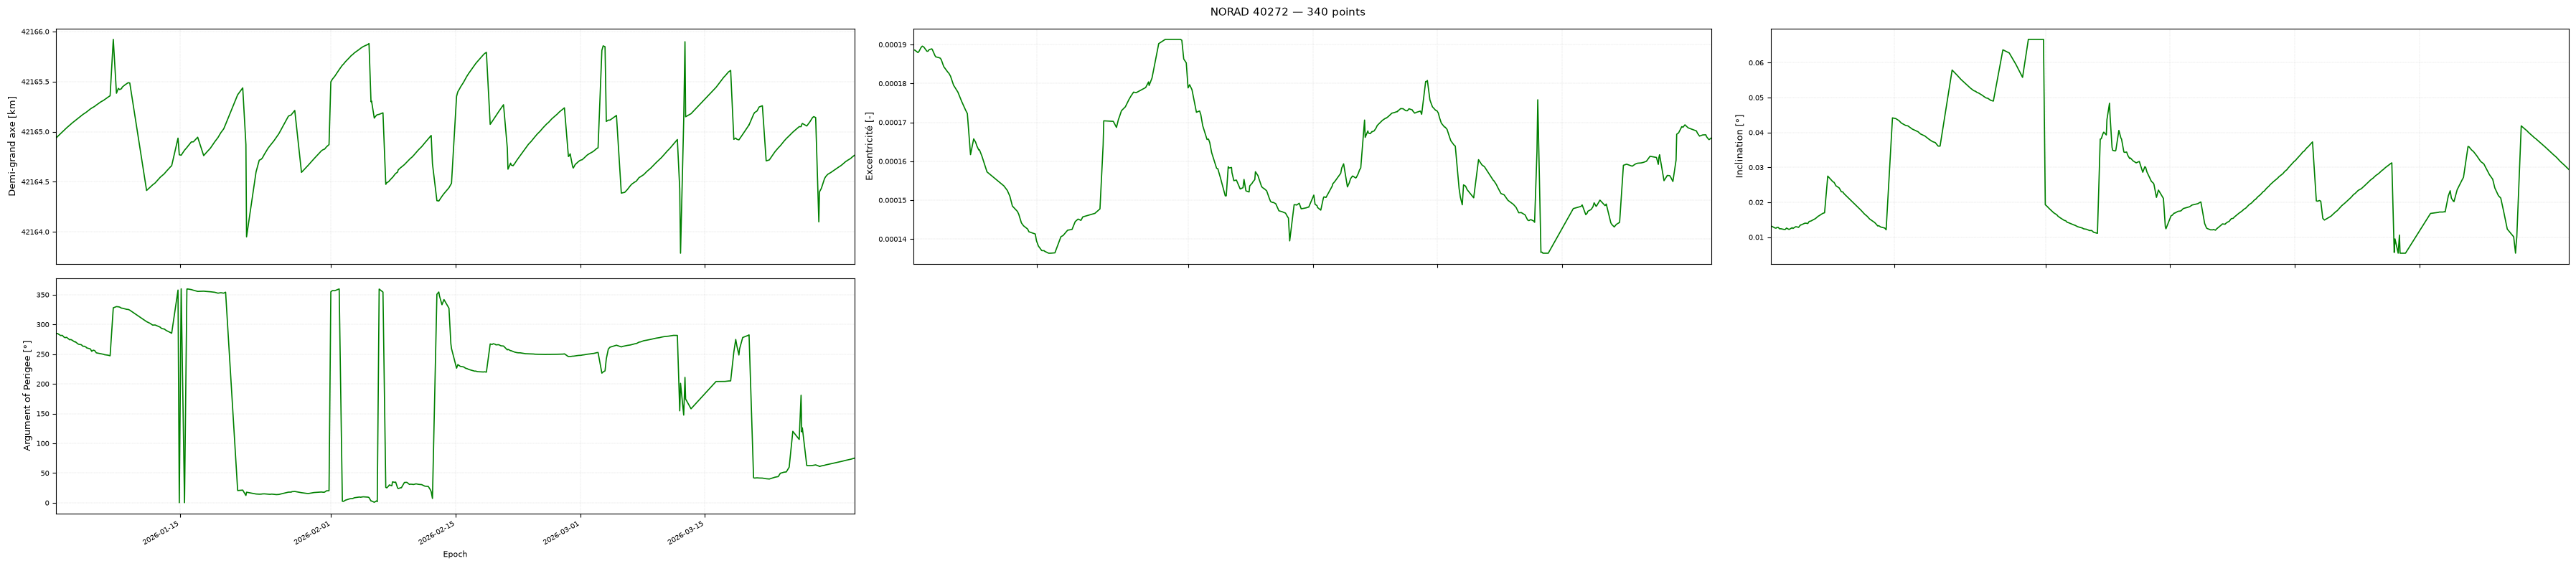

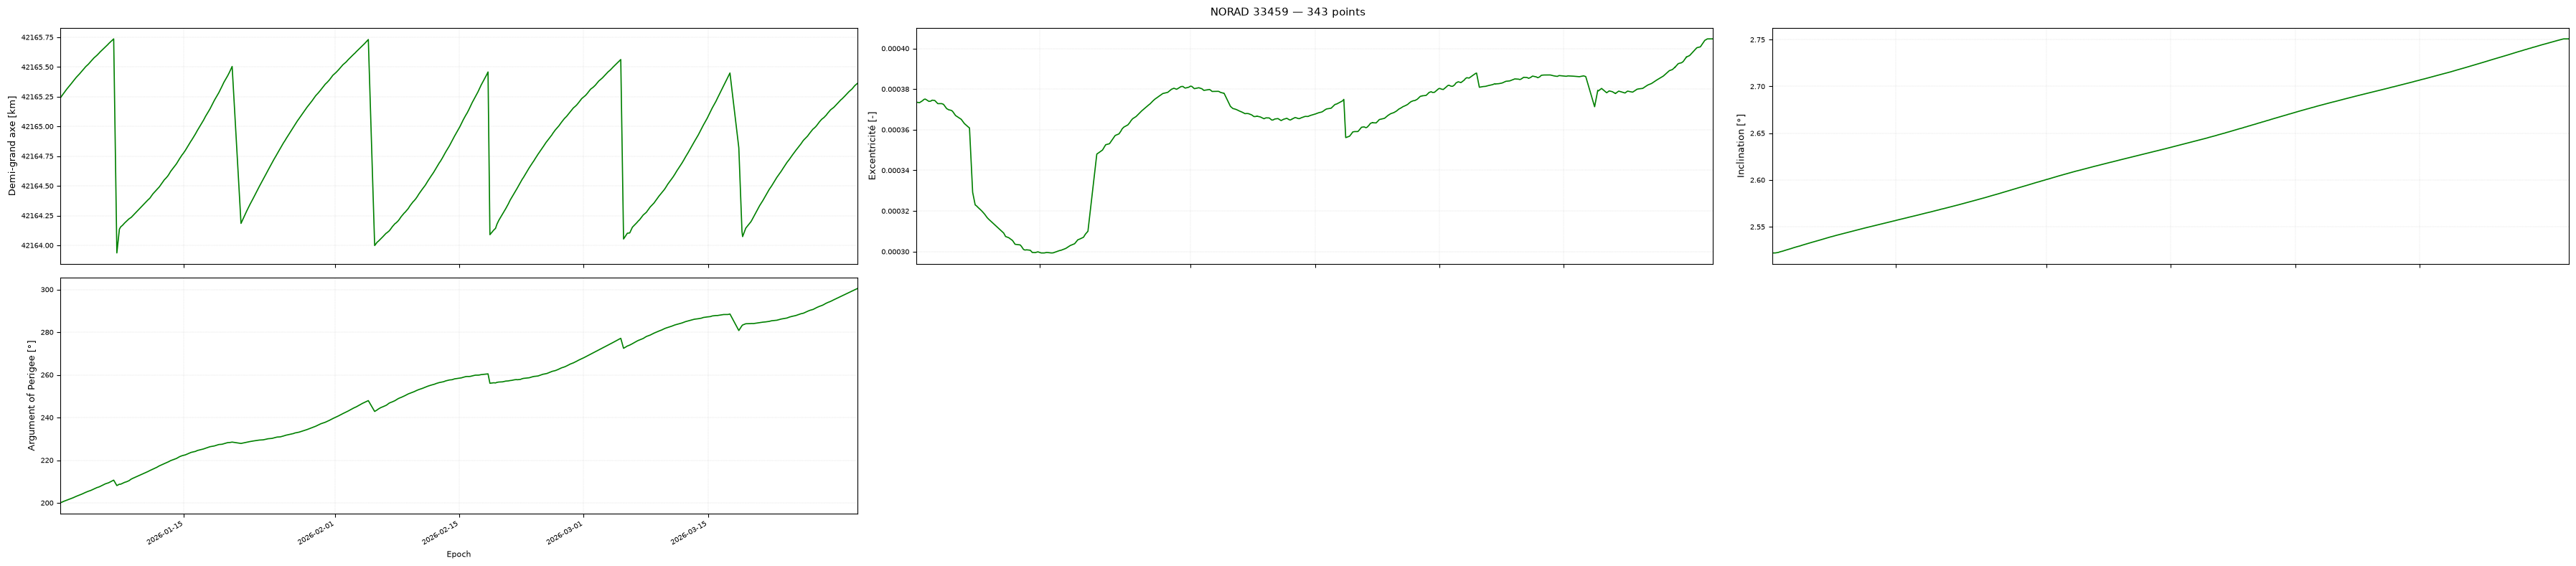

In [20]:
params= ['sma', 'eccentricity', 'inclination', 'arg_perigee']
## Satellite argentin ARSAT-1, 40272, GEO d'inclinaison quasi nulle. En orbite depuis 2014. Purpose = TV 
plot_time_series(path_geo, 40272, params)

## Satellite européen EUTE HOT BIRD 13C - 33459
plot_time_series(path_geo, 33459, params);


## Premières méthodes de détection in-plane de manoeuvre par filtrage Mean Longitude Filter et filtre Kalman d'ordre 1 et 2

On se base sur l'article de Zollo et al (2023), et on applique d'abord la méthode MLF au satellite GEO METEOSAT10, NORAD 38552

In [21]:
print(f"Norad de METEOSAT-10 dans la base de données GEO: {38552 in norads_geo}")

path_eume = ROOT / "data" / "raw" / "ALL_EUME_1782819336.5507112.parquet"

norads_eume = pl.scan_parquet(path_eume).select("norad").unique().sort("norad").collect().to_series().to_list()
print(f"{len(norads_eume)} norads récupérés pour les satellites européens EUME, tous types de satellites confondus.")
print(f"Norad de METEOSAT-10 dans la base de données EUME : {38552 in norads_eume}")

Norad de METEOSAT-10 dans la base de données GEO: False
10 norads récupérés pour les satellites européens EUME, tous types de satellites confondus.
Norad de METEOSAT-10 dans la base de données EUME : True


In [22]:
# Satellite METEOSAT_10 : norad 38552
norad = 38552
params = ['sma', 'eccentricity', 'inclination', 'arg_perigee']
def meteosat_10_time_series():
    fig = plot_time_series(path_eume, norad, params)
    save_fig(fig, f"METEOSAT-10_norad_{norad}_all_params")

In [23]:
# Méthode Mean-Longitude-Filter for East-West maneuver detection

import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess 

## récuperation du dataframe 
print(pl.scan_parquet(path_eume).collect_schema().names())
df = (
    pl.scan_parquet(path_eume).filter(pl.col('norad') == norad)
    .select('epoch', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity','bstar' )
    .sort('epoch').collect()
)


['norad', 'object_name', 'epoch', 'creation_date', 'rev_at_epoch', 'inclination', 'raan', 'arg_perigee', 'mean_anomaly', 'mean_motion', 'eccentricity', 'bstar', 'sma', 'apogee', 'period', 'velocity']


In [24]:
from maneuver_detection.mean_longitude_filter import MLF_LOWESS_KEPLERIAN, MLF_LOWESS_SGP4
## Test 
def test_MLF_LOWESS(df, norad):
    fig = MLF_LOWESS_KEPLERIAN(df, norad)
    fig_ = MLF_LOWESS_SGP4(df, norad)
    save_fig(fig, f"MLF_LOWESS_KEPLERIAN_norad_{norad}")
    save_fig(fig_, f"MLF_LOWESS_SGP4_norad_{norad}")

On va tester cette méthode sur d'autres satellites GEO

In [25]:
def test_MLF_GEOS(df, norad):
    path_geo = ROOT / "data" / "raw" / "ALL_ALL_1782740361.841526.parquet"
    path_geo_2 = ROOT / "data" / "raw" / "ALL_ALL_1782820382.5801358.parquet"
    norads_geo = pl.scan_parquet(path_geo).select("norad").unique().sort("norad").collect().to_series().to_list()
    print(f"{len(norads_geo)} norads récupérés pour tous satellites GEO depuis 1er janvier 2026.")

    norads = random.sample(norads_GEO_, 5)

    for n in norads : 
        df  = (
        pl.scan_parquet(path_geo).filter(pl.col('norad') == n)
        .select('epoch', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
        .sort('epoch').collect()
        )
        plot_time_series(path_geo, n , 'sma')
        MLF_LOWESS_SGP4(df, n, threshold_sigma=2)

On voit une claire corrélation entre des variations de semi-grand axe et des pics dans les différences de mean_longitude pour ces satellites GEO. Remarque : dans Zollo et al (2023), ce dernier utilise une métrique de seuil qui n'est pas basée sur la statisqtiques des données, mais plutôt sur un seuil de proéminence topographique (i.e. hauteur d'un pic relativement à la courbe de niveau la plus basse autour de ce pic qui ne contient pas de plus haut pic). 
Il optimise les paramètres du smoothing, donc dans le cas de MLF il ne s'agit que du paramètres tau de kernel gaussien glissant.
Ce paramètre est optimisé via une recherche du minimum de la fonction 1/F1 (définie à partir de la matrice de confusion). Question : pour obtenir cette matrice ne faut il pas des données opérateurs de manoeuvres ??
On a ici simplement utilisé un seuillage statistique dans un premier temps. 


On va maintenant comparer avec une technique de filtration Kalman sur un historique de valeurs du demi-grand-axe d'un satellite, adapté à des epochs non régulières de récupération de données. cf src/maneuver_detection/discrete_kalman_filter.py. 
Les paramètres à chosir sont les suivants : $var_Q = 0.13$ par défaut, variance du bruit gaussien ajouté lors de la transition. $r = 1km^2 $ par défaut, incertitude sur la mesure du semi-grand axe. 

On trace les deux métriques de l'article original : $ \varepsilon = ySy^T$ résidus normalisés, qui suivent une loi du $\chi ^2$, avec un seuil défini par un quantile de cette distribution, et l'estimée de $\dot{a}$ 

In [26]:
from maneuver_detection.discrete_kalman_filter import kalman_filter_ordre_1 , kalman_filter_ordre_2, detect_kalman
from maneuver_detection.compare import compare_methods

def test_kalman_vs_MLF():
    path_eume = ROOT / "data" / "raw" / "ALL_EUME_1782819336.5507112.parquet"
    norad = 38552

    df = (
        pl.scan_parquet(path_eume).filter(pl.col('norad') == norad)
        .select('epoch', 'sma')
        .sort('epoch').collect()
    )

    print(f"On applique la filtration Kalman sur le satellite METEOSAT-10, norad :{norad}")
    detect_kalman(df, r = 1e-1 , alpha = 0.997); 

    ## On compare avec la technique MLF 
    df_ = (
        pl.scan_parquet(path_eume).filter(pl.col('norad') == norad)
        .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
        .sort('epoch').collect()
        )

    MLF_LOWESS_SGP4(df_, norad)

    # on utilise directement compare.py

    compare_methods(df_, norad, r=0.23)
    plot_time_series(path_eume, norad, 'sma'); 


Cette première comparaison est plutot concluante, les filtres détectent effectievement des manoeuvres là ou on pourrait s'y attendre à la vue de l'historique du demi-grand axe. La puissante du filtrage Kalman est son efficacité également en LEO. 
La difficulté de toutes ses méthodes est toujours la question de la définition d'un seuillage qui repère les manoeuvres et qui exclu le bruit de mesure : d'où la necessité de faire du ML dans un second temps. 

## Récup de plot pour doc caract manoeuvres 

On cherche ici à caractériser les différents PoL de satellites GEO. 
On retient ces deux Norads : 
- 43226 : Satellite US. "GOES-17 is a geostationary weather satellite designed to improve the forecasts of weather, ocean, and environment by providing faster and more detailed data, real-time images of lightning, and advanced monitoring of solar activities and space weather"
- 66142 : Satellite Chinois (aucun info)

In [27]:


def figures_latex_1(): 
    norad_1 = 43226 
    norad_2 = 66142 

    path = ROOT/ "data" / "raw" / "ALL_ALL_1782740361.841526.parquet"
    norads = pl.scan_parquet(path).select("norad").unique().sort("norad").collect().to_series().to_list()

    print(f"Norad {norad_1} in path : {norad_1 in norads}")
    print(f"Norad {norad_2} in path : {norad_2 in norads}")

    df_1 = (
            pl.scan_parquet(path).filter(pl.col('norad') == norad_1)
            .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
            .sort('epoch').collect()
            )
    df_2 = (
        pl.scan_parquet(path).filter(pl.col('norad') == norad_2)
        .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
        .sort('epoch').collect()
        )

    fig1 = plot_time_series(path, norad_1, "sma")
    fig2 = plot_time_series(path, norad_2, "sma")
    fig3 = compare_methods(df_1, norad_1, var_Q= 0.13, r = 0.05, alpha= 0.997)
    fig4 = compare_methods(df_2, norad_2, var_Q= 0.13, r = 0.05, alpha= 0.997)

    save_fig(fig1, name=f"norad_{norad_1}_sma")
    save_fig(fig2, name=f"norad_{norad_2}_sma")
    save_fig(fig3, name=f"norad_{norad_1}_manoeuvres")
    save_fig(fig4, name=f"norad_{norad_2}_manoeuvres")



Norad 43226 in path : True
Norad 66142 in path : True


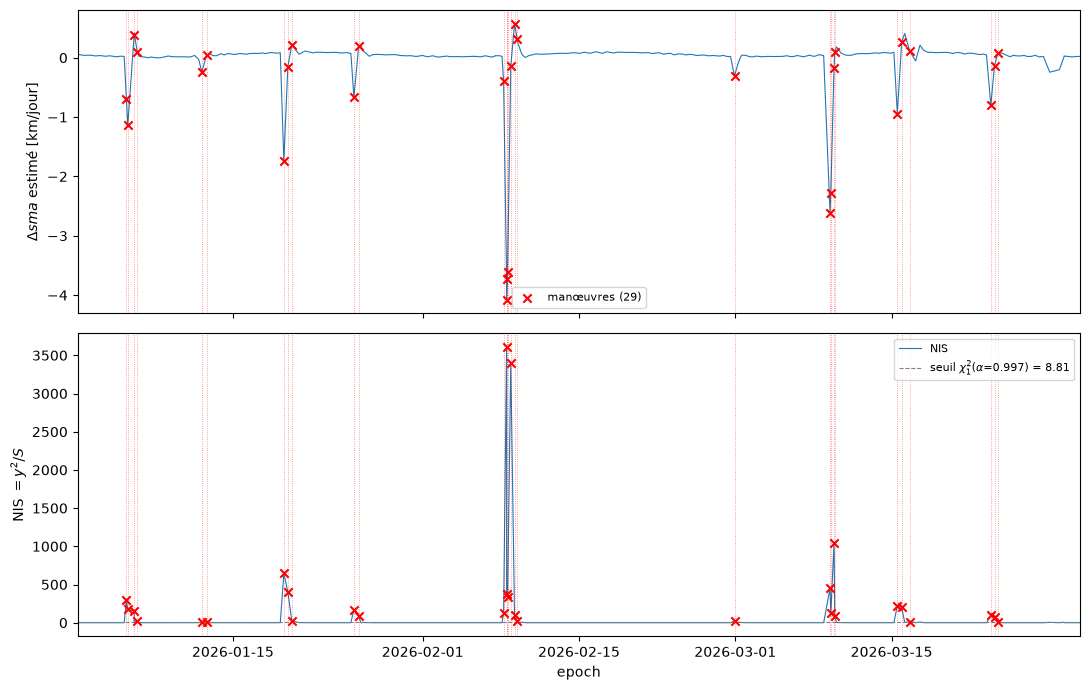

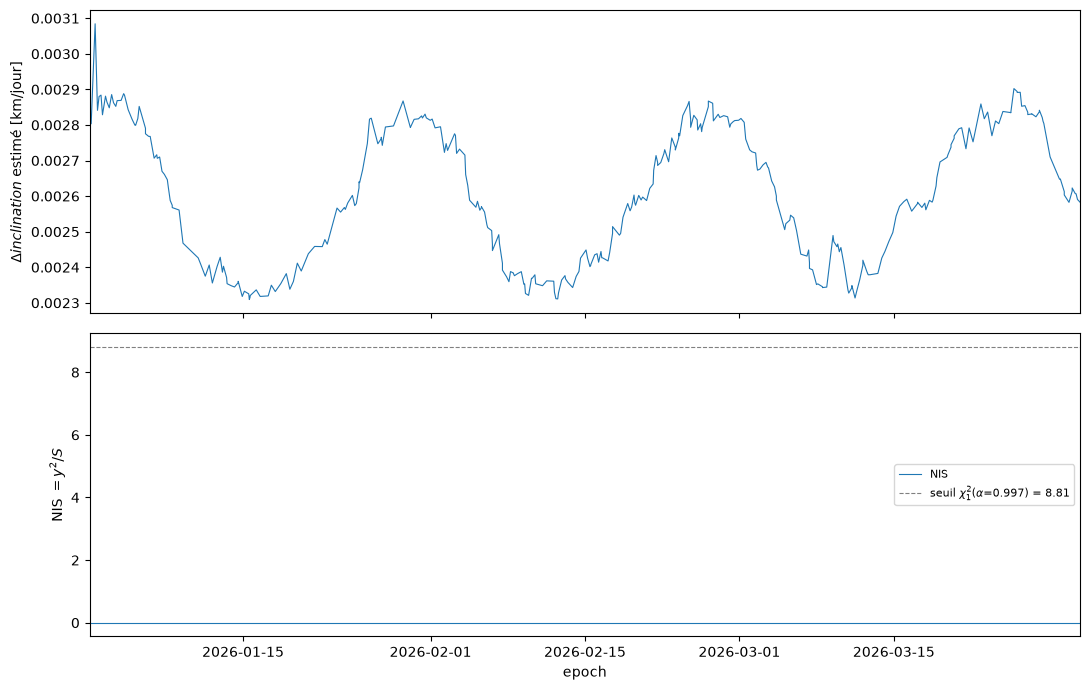

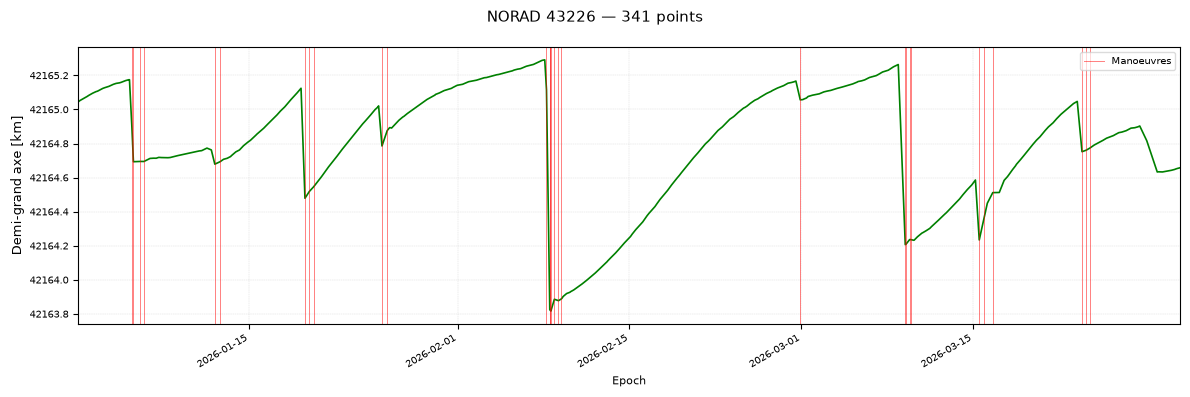

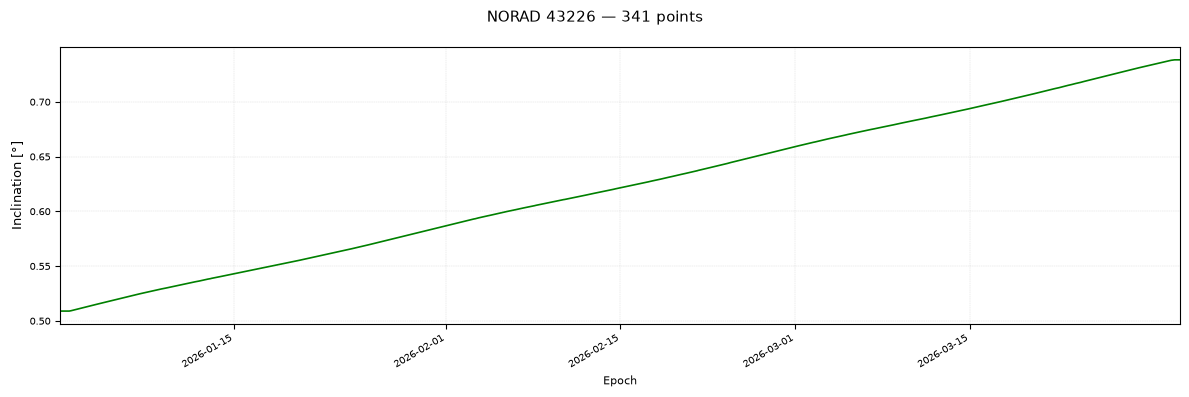

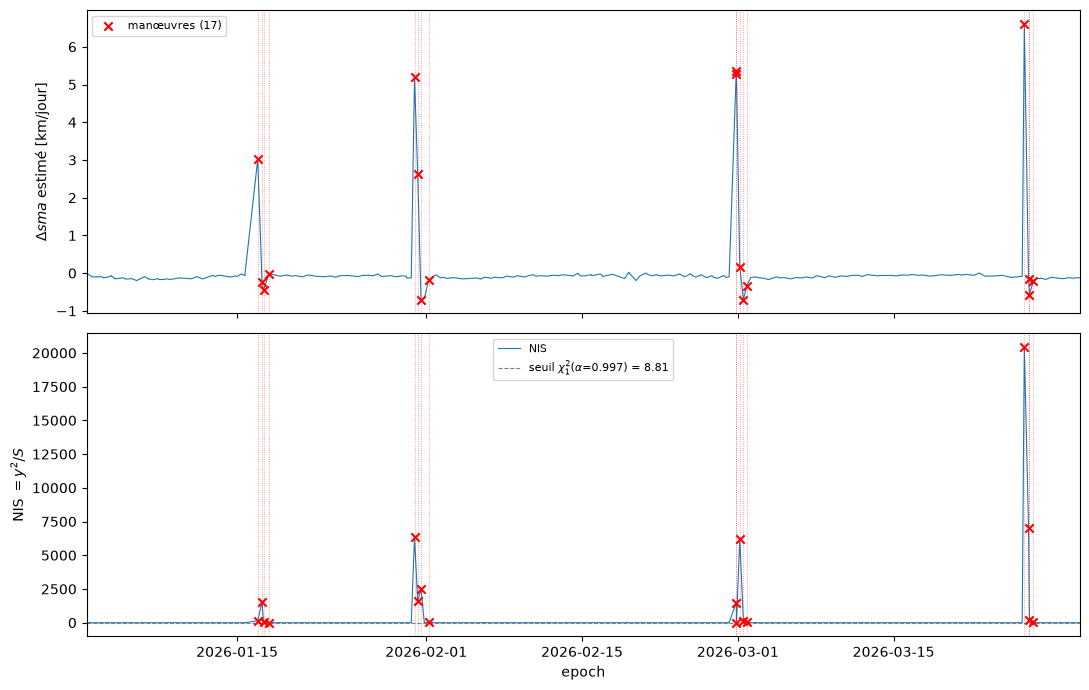

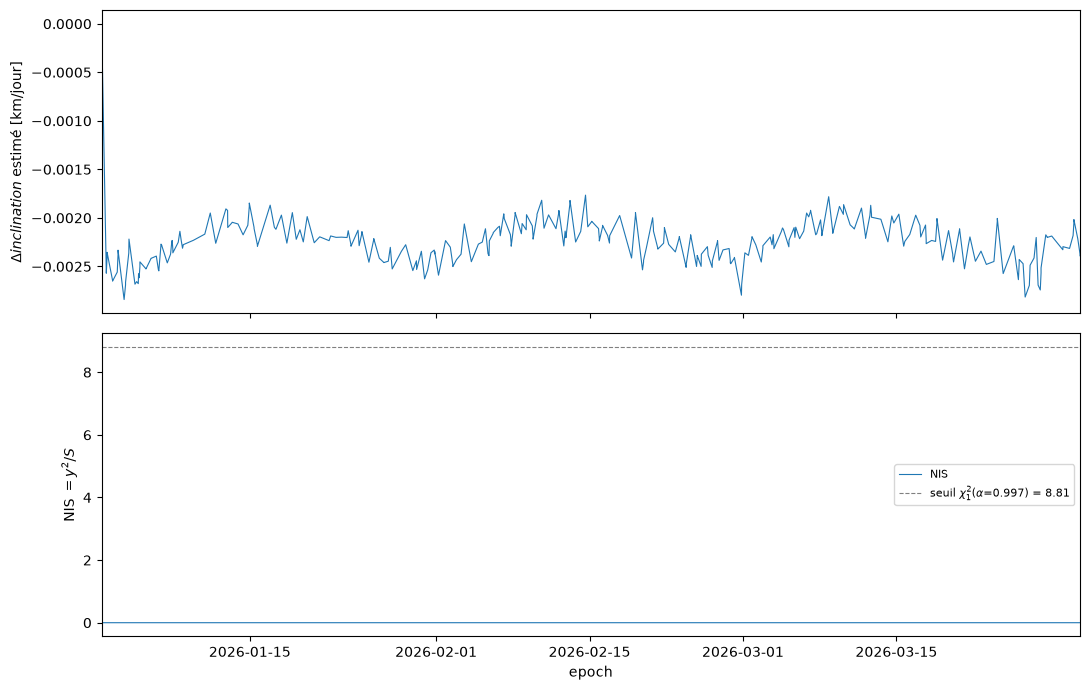

/Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/.venv/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


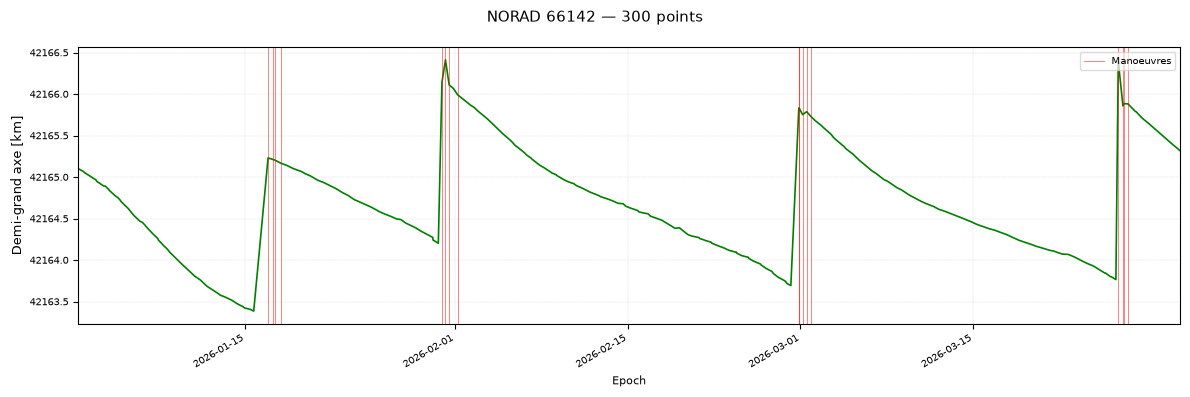

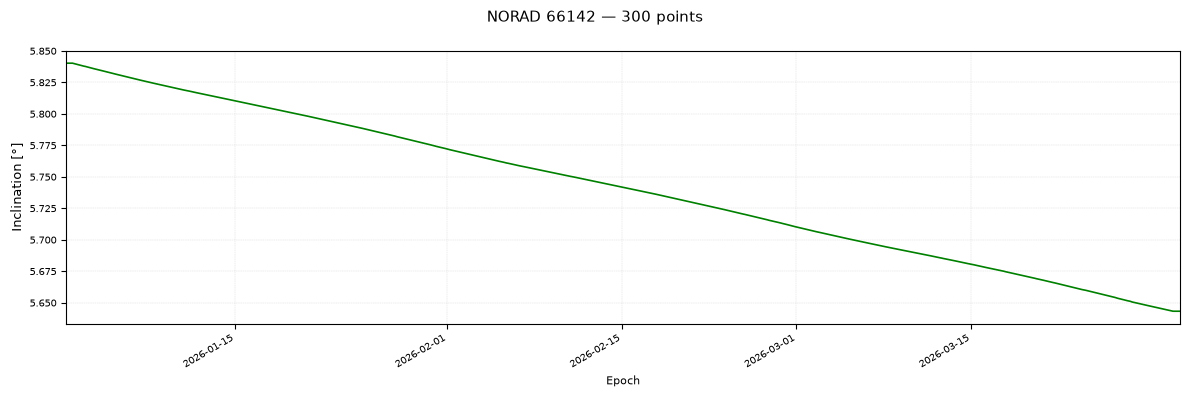

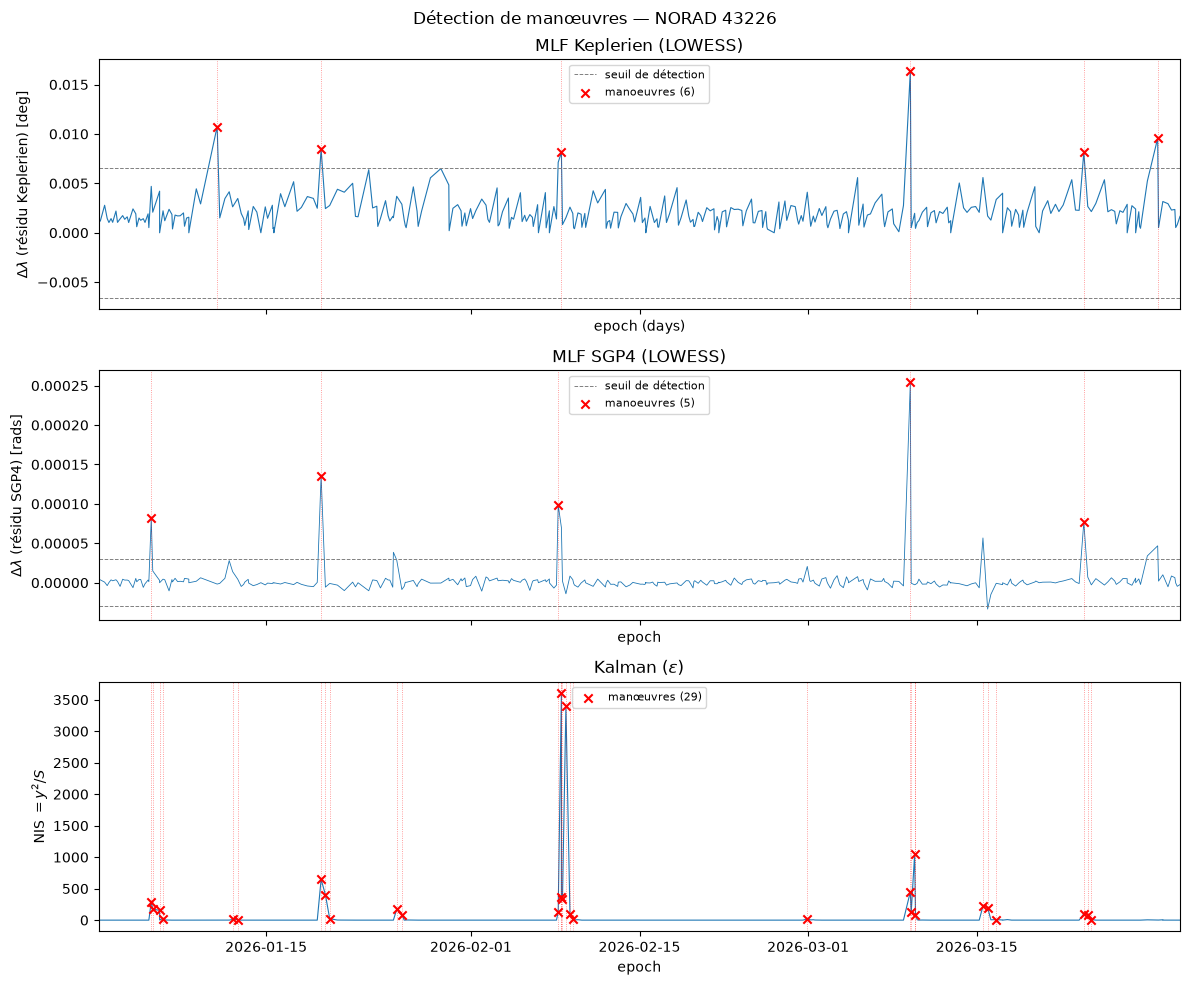

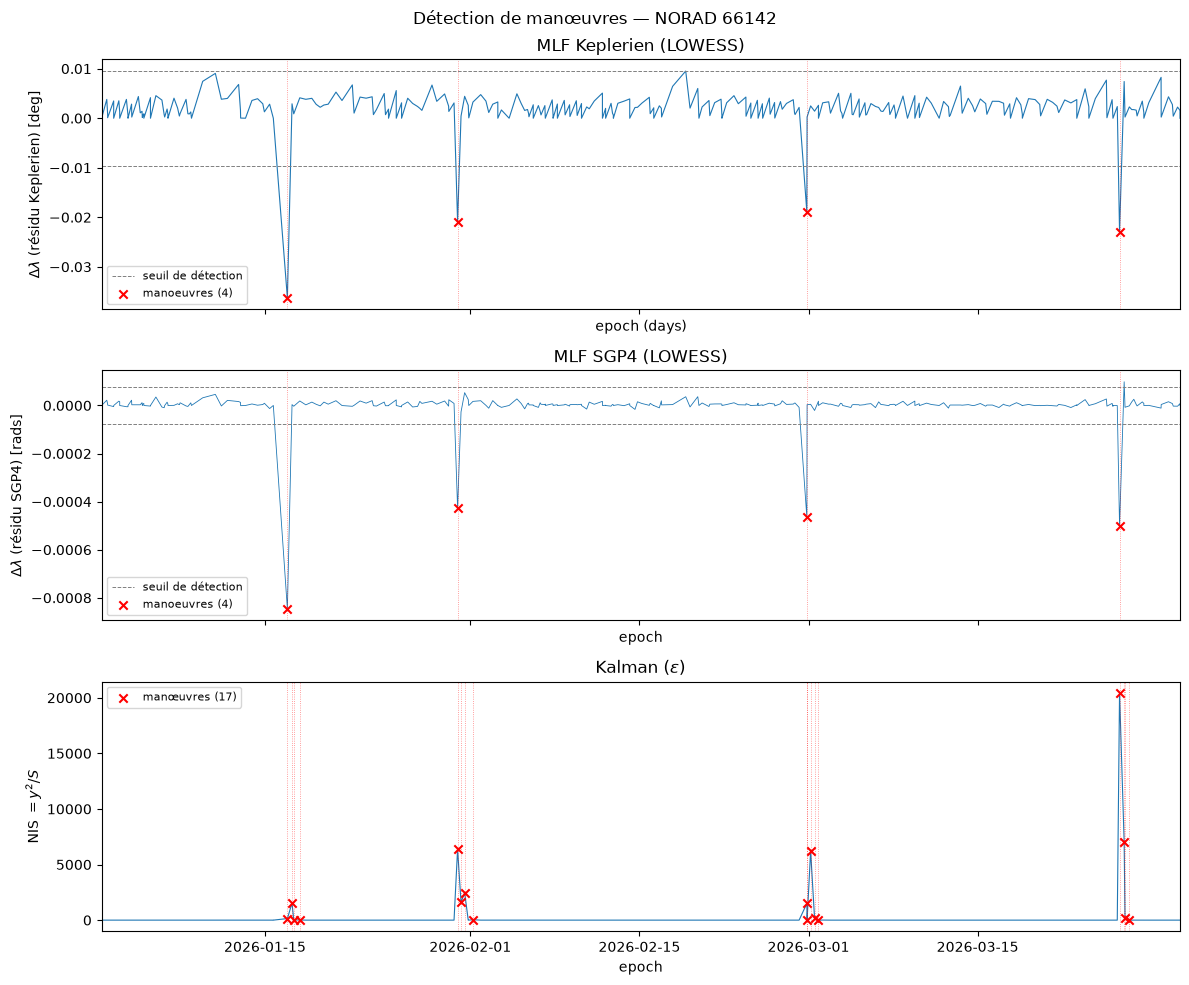

Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/norad_43226_sma_and_maneuvers.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/norad_66142_sma_and_maneuvers.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/norad_43226_methods.png
Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/norad_66142_methods.png


In [105]:

def figures_latex_2(saving=False): 
    norad_1 = 43226 
    norad_2 = 66142 

    path = ROOT/ "data" / "raw" / "ALL_ALL_1782740361.841526.parquet"
    norads = pl.scan_parquet(path).select("norad").unique().sort("norad").collect().to_series().to_list()

    print(f"Norad {norad_1} in path : {norad_1 in norads}")
    print(f"Norad {norad_2} in path : {norad_2 in norads}")

    df_1 = (
            pl.scan_parquet(path).filter(pl.col('norad') == norad_1)
            .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
            .sort('epoch').collect()
            )
    df_2 = (
        pl.scan_parquet(path).filter(pl.col('norad') == norad_2)
        .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
        .sort('epoch').collect()
        )

    
    epoch_1, sma_dot_1, nis, maneuvers_1, treshold_1 = detect_kalman(df_1, ordre=1, r = 8e-5, var_Q=0.05, p0=1000, metrique='sma')
    epoch_2, i_dot_2, nis_2, maneuvers_2, treshold_2 = detect_kalman(df_1, ordre=1, r = 0.005, var_Q=0.05, p0=1000, metrique='inclination')
    
    fig1 = plot_time_series(path, norad_1, "sma", maneuvers=epoch_1[maneuvers_1])
    fig2 = plot_time_series(path, norad_1, "inclination", maneuvers= epoch_2[maneuvers_2])

    
    epoch_3, sma_dot_3, nis, maneuvers_3, treshold_3 = detect_kalman(df_2, ordre=1, r = 8e-5, var_Q=0.05, p0=1000, metrique='sma')
    epoch_4, i_dot_4, nis_4, maneuvers_4, treshold_4 = detect_kalman(df_2, ordre=1, r = 8e-5, var_Q=0.05, p0=1000, metrique='inclination')
    
    fig3 = plot_time_series(path, norad_2, "sma", maneuvers=epoch_3[maneuvers_3])
    fig4 = plot_time_series(path, norad_2, "inclination", maneuvers= epoch_4[maneuvers_4])
    
    fig5 = compare_methods(df_1, norad_1, var_Q= 0.05, r = 8e-5, alpha= 0.997)
    fig6 = compare_methods(df_2, norad_2, var_Q= 0.05, r = 8e-5, alpha= 0.997)

    if saving : 
        save_fig(fig1, name=f"norad_{norad_1}_sma_and_maneuvers")
        save_fig(fig3, name=f"norad_{norad_2}_sma_and_maneuvers")
        save_fig(fig5, name=f"norad_{norad_1}_methods")
        save_fig(fig6, name=f"norad_{norad_2}_methods")
figures_latex_2(True)

## Test de la méthode par filtration Kalman 2 
On implémente une filtration Kalman d'ordre 2 (i.e. seul la dérivée seconde du semi-grand axe est considérée localement constante)

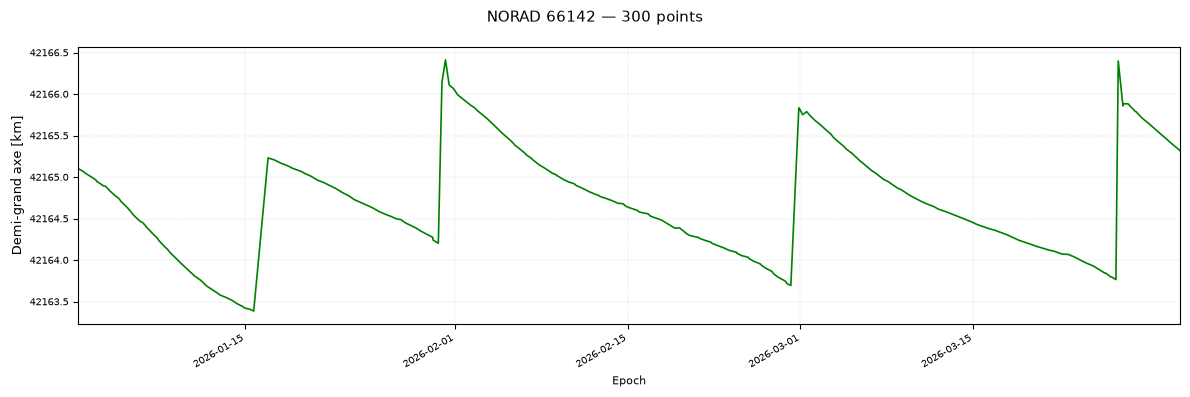

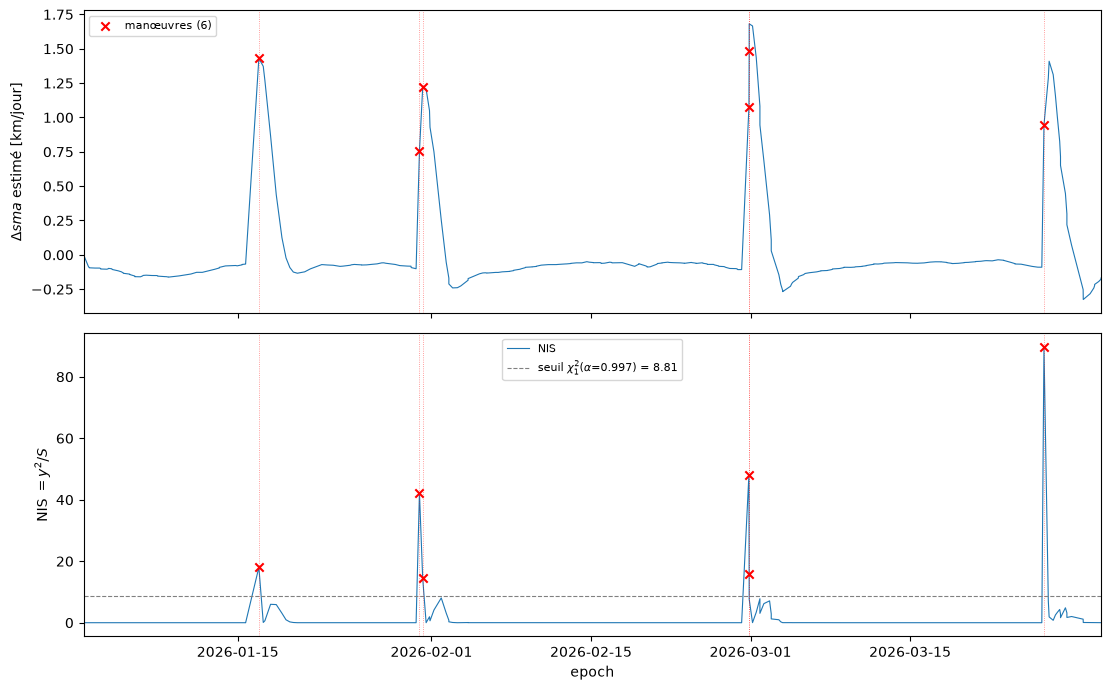

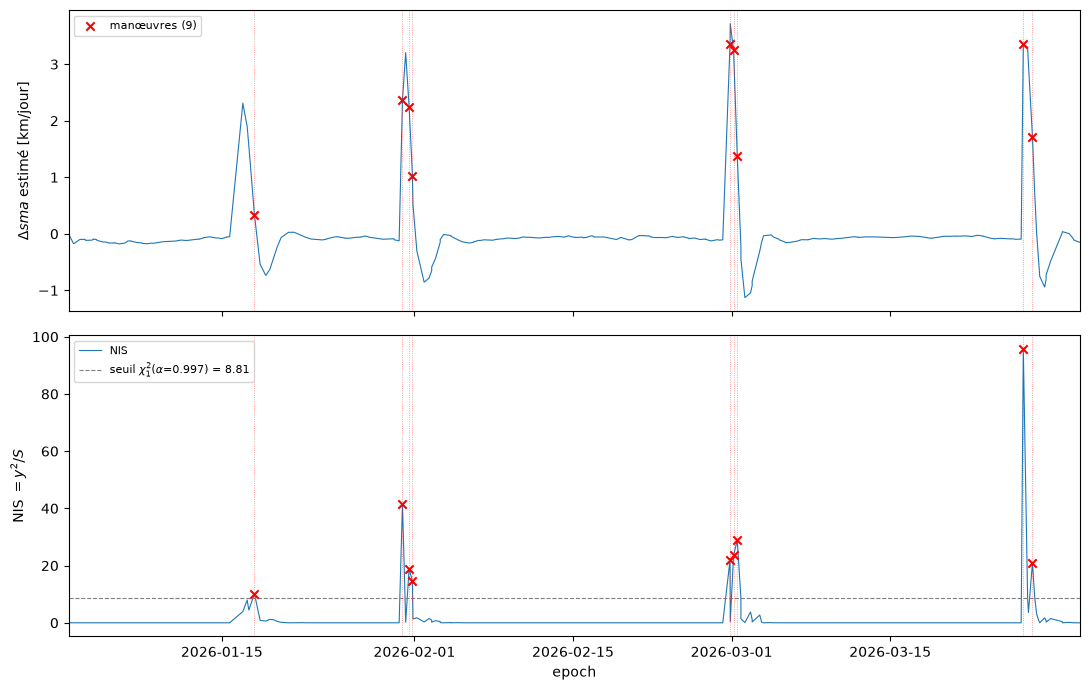

In [106]:
def test_kalman_2():
    norad_2 = 66142
    path = ROOT/ "data" / "raw" / "ALL_ALL_1782740361.841526.parquet"
    df_2 = (
        pl.scan_parquet(path).filter(pl.col('norad') == norad_2)
        .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
        .sort('epoch').collect()
        )
    plot_time_series(path, norad_2, "sma")
    detect_kalman(df_2, ordre=1, r = 0.05, alpha = 0.997)
    detect_kalman(df_2, ordre=2, var_Q= 0.13,r = 0.03, alpha = 0.997)
test_kalman_2()

# Construction d'un dataset labellisé solide
## L'ILRS met a disposition des maneuvres 

Voici ce que contient une ligne du fichier cs2man.txt récupéré en libre accès depuis le site de l'ILRS qui correspond aux manoeuvres du satellite Cryosat-2 Norad 36508 entre 2010 et 2026 : el

CRYO2  # Identifiant satellite 

2026 182 19 53 # date début de manoeuvre

2026 182 19 55    # date fin de manoeuvre 

006     # type de paramètres, dans ce cas : $\Delta v_r, \Delta v_u , \Delta v_h, a_r, a_u, a_h , \Delta_a (pred, measured)$ 

1 #nombre de burns 

2026 182 19 54 12.038   # date mediane du burn en Année/Jour/Heure/Minute/Secondes.ms

01.2500000000000e+02  # Durée du boost

-1.8954357500000e-04 # $\Delta v_r $ 

01.4479253750000e-02 #  $\Delta v_u$ , composante clé, variation de vitesse transverse.

01.3338918750000e-04 # $\Delta v_h$


-1.5163486000000e+00 # $a_r$

01.1583403000000e+02 # $a_u$

01.0671135000000e+00  # $a_h$ 

00.0000000000000e+00 
00.0000000000000e+00 
00.0000000000000e+00



On récupère les donnnées du satellites via la data.yaml en entrant le nom ILRS du satellite CryoSat-2 -> "cs2".
On va maintenant regarder les données orbitales de ce satellite.


Norad 36508 in path : True


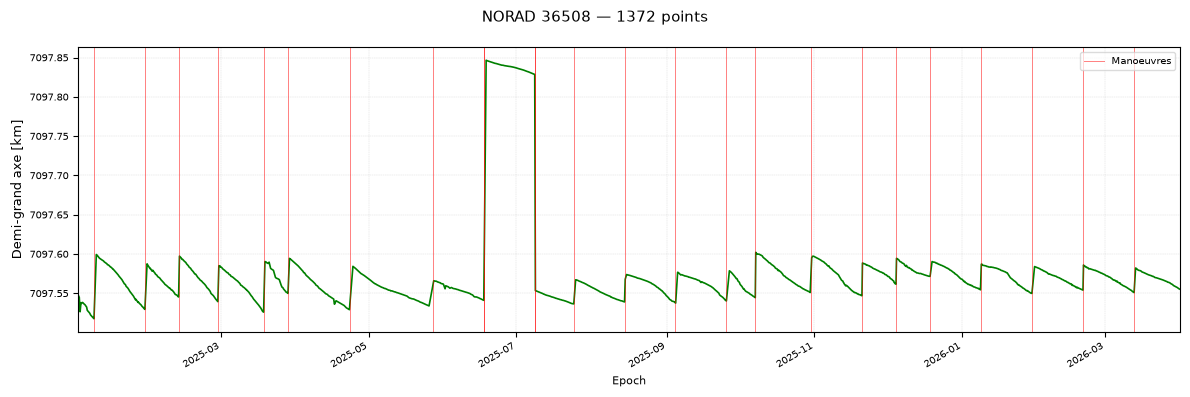

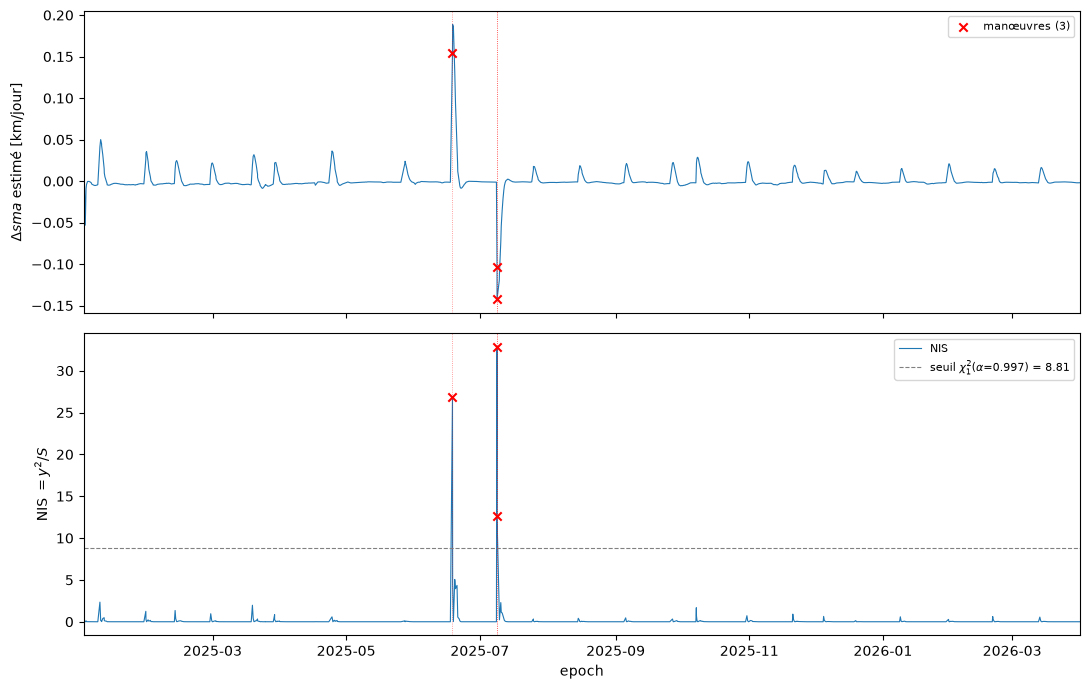

In [107]:
from config import load_data_config
from datetime import datetime, time


def test_maneuvers(): 
    path_TLE = ROOT / "data" / "raw" / "CRYOSAT_ESA_1783006097.0149062.parquet"
    norads = pl.scan_parquet(path_TLE).select("norad").unique().sort("norad").collect().to_series().to_list()
    
    norad = 36508
    print(f"Norad {norad} in path : {norad in norads}")

    path_maneuvers_cs2 = ROOT / "data" / "raw" / "cs2_man_ILRS.parquet"
    df_man = pl.scan_parquet(path_maneuvers_cs2).collect()
    
    maneuvers_dates= df_man.select('burn_epoch').to_series().to_list()
    #config = load_data_config(ROOT / "configs" / "data.yaml")
    #start = datetime.combine(config.data_range.start, time.min)
    #end   = datetime.combine(config.data_range.end,   time.min)
    ## On plot les dates des maneuvres sur une ligne de temps pour visualiser les dates des maneuvres du satellite CS2, on a juste ajouté une liste maneuvers_date en argument de plot_time_series
    df_TLE= (
        pl.scan_parquet(path_TLE).filter(pl.col('norad') == norad)
        .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
        .sort('epoch').collect()
        )
    
    ep = df_TLE["epoch"].to_numpy()
    xlim = (ep[0], ep[-1])
    plot_time_series(path_TLE, norad, 'sma', start=ep[0], end=ep[-1], maneuvers=maneuvers_dates, xlim=xlim)

    ## On a optimisé les paramètres et le seuillage simultanément via optimise_seuil.py
    detect_kalman(df_TLE, ordre=1, var_Q= 0.001692, r = 0.001273, p0 = 9.99e+04 , alpha= 0.997, xlim=xlim)

test_maneuvers()


Norad 36508 in path : True


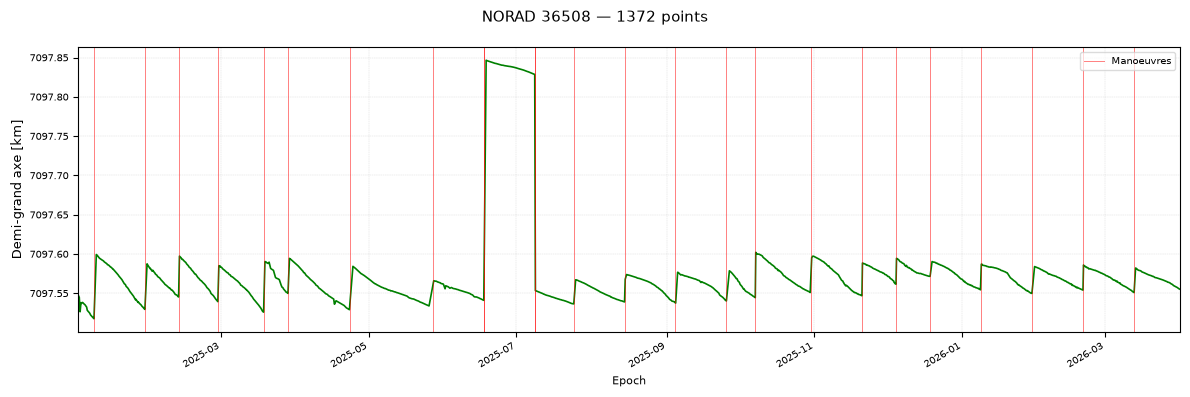

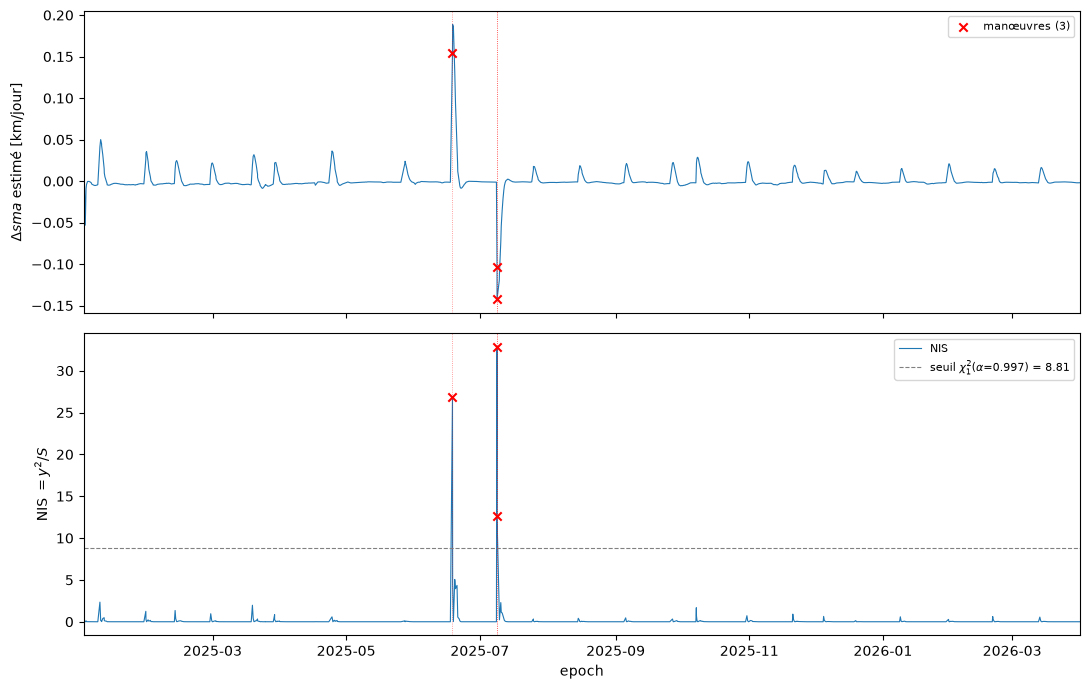

In [108]:


def test_maneuvers_optimized_params(): 
    path_TLE = ROOT / "data" / "raw" / "SENTINEL_ALL_1783007466.119748.parquet"
    norads = pl.scan_parquet(path_TLE).select("norad").unique().sort("norad").collect().to_series().to_list()
    
    norad = 43437
    print(f"Norad {norad} in path : {norad in norads}")

    path_maneuvers = ROOT / "data" / "raw" / "s3b_man_ILRS.parquet"
    df_man = pl.scan_parquet(path_maneuvers).collect()
    
    maneuvers_dates= df_man.select('burn_epoch').to_series().to_list()

    ## On plot les dates des maneuvres sur une ligne de temps pour visualiser les dates des maneuvres du satellite CS2, on a juste ajouté une liste maneuvers_date en argument de plot_time_series
    df_TLE= (
        pl.scan_parquet(path_TLE).filter(pl.col('norad') == norad)
        .select('epoch', 'sma', 'mean_motion', 'raan', 'arg_perigee', 'mean_anomaly', 'inclination', 'eccentricity')
        .sort('epoch').collect()
        )
    
    ep = df_TLE["epoch"].to_numpy()
    xlim = (ep[0], ep[-1])
    
    plot_time_series(path_TLE, norad, 'sma', start=ep[0], end=ep[-1], maneuvers=maneuvers_dates, xlim=xlim)

    ## On a optimisé les paramètres et le seuillage simultanément via optimise_seuil.py
    detect_kalman(df_TLE, ordre=1, var_Q= 0.001692, r = 0.001273, p0 = 9.99e+04 , alpha= 0.997, xlim=xlim)

test_maneuvers()


## Observation de Envisat

"The Envisat (Environmental Satellite) satellite is an Earth-observing satellite built by the European Space Agency. It was launched on March 1, 2002 aboard an Ariane 5 into a Sun synchronous polar orbit at a height of 790 km (±10 km). It orbits the Earth in about 101 minutes with a repeat cycle of 35 days"

In [109]:
path_esa = ROOT / "data" / "raw" /"ALL_ESA_1782747586.801861.parquet"

norads_esa = pl.scan_parquet(path_esa).select("norad").unique().sort("norad").collect().to_series().to_list()

print(f"{len(norads_esa)} norads ESA récupérés, tous types de satellites confondus.")

98 norads ESA récupérés, tous types de satellites confondus.


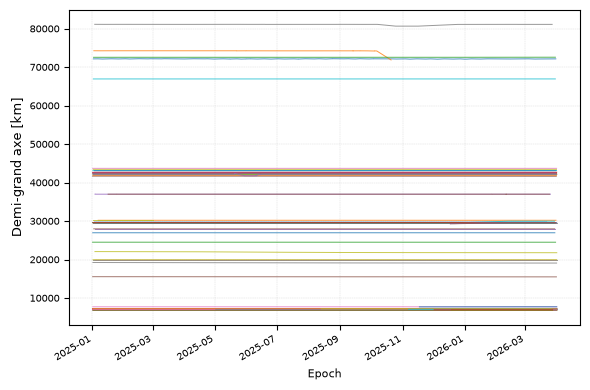

In [110]:
fig_esa = plot_compare(path_esa, norads_esa, "sma")

On a encore une fois tous les types de satellites, LEO, GEO, ... On s'interesse au NORAD 27386 = ENVISAT

In [111]:
norad = 27386

params = ['sma', 'eccentricity', 'inclination', 'arg_perigee'] 

fig = plot_time_series(path_esa, norad, params)
save_fig(fig, f"norad_{norad}_all_params")


Figure écrite dans /Users/etiennechevrolat/Desktop/Ecole_polytechnique/STAGE 2026/Aldoria/ssa-analysis/data/graphs/norad_27386_all_params.png


Comment détecter des manoeuvres dans ces courbes de satellites LEO ? 